# Advanced Analytics: Violence Classification using a CNN + Encoder Architecture

 Lourenco Debonnet , Marvin Hahne , Kevin Le

# 1. Colab Set-up

## 1.1 Install packages

In [1]:
!pip -q install decord


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 97.8 MB/s eta 0:00:00


## 1.2 Connect to GoogleDrive

In [2]:
from google.colab import drive


drive.mount('/content/drive')

Mounted at /content/drive


Set Paths

In [3]:
from pathlib import Path

# ============================================================
# PATH CONFIGURATION
# Change only PROJECT_ROOT when using another Drive location.
# ============================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/Advanced Analytics")

# ----------------------------
# Input data
# ----------------------------

DATASET_ROOT = (
    PROJECT_ROOT
    / "kaglle_violence (Unzipped Files)"
    / "Real Life Violence Dataset"
)

EXTERNAL_DATASET_ROOT = (
    PROJECT_ROOT
    / "New violence data"
    / "ADA new violence dataset (Unzipped Files)"
    / "violence-detection-dataset"
)

INFERENCE_VIDEO_DIR = PROJECT_ROOT / "inference_videos"

SAMPLE_VIDEO = DATASET_ROOT / "Violence" / "V_1.mp4"

# ----------------------------
# Intermediate data
# ----------------------------

FRAMES_PAD_DIR = PROJECT_ROOT / "frames"
FRAMES_CROP_DIR = PROJECT_ROOT / "frames_crop"

EMBEDDINGS_DIR = PROJECT_ROOT / "embeddings_resnet50"
AUGMENTED_EMBEDDINGS_DIR = PROJECT_ROOT / "embeddings_augmented"

# ----------------------------
# Dataset splits
# ----------------------------

SPLITS_DIR = PROJECT_ROOT

TRAIN_SPLIT_CSV = SPLITS_DIR / "train_split.csv"
VAL_SPLIT_CSV = SPLITS_DIR / "val_split.csv"
TEST_SPLIT_CSV = SPLITS_DIR / "test_split.csv"

SPLIT_CSVS = {
    "train": TRAIN_SPLIT_CSV,
    "val": VAL_SPLIT_CSV,
    "test": TEST_SPLIT_CSV,
}

# ----------------------------
# Model outputs
# ----------------------------

OUT_DIR = PROJECT_ROOT / "outputs"

# Only create output directories.
# Input directories should already exist.
for directory in [
    FRAMES_PAD_DIR,
    FRAMES_CROP_DIR,
    EMBEDDINGS_DIR,
    AUGMENTED_EMBEDDINGS_DIR,
    OUT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root:        {PROJECT_ROOT}")
print(f"Main dataset:        {DATASET_ROOT}")
print(f"External dataset:    {EXTERNAL_DATASET_ROOT}")
print(f"Frames:              {FRAMES_PAD_DIR}")
print(f"Cropped frames:      {FRAMES_CROP_DIR}")
print(f"Embeddings:          {EMBEDDINGS_DIR}")
print(f"Model outputs:       {OUT_DIR}")

Project root:        /content/drive/MyDrive/Advanced Analytics
Main dataset:        /content/drive/MyDrive/Advanced Analytics/kaglle_violence (Unzipped Files)/Real Life Violence Dataset
External dataset:    /content/drive/MyDrive/Advanced Analytics/New violence data/ADA new violence dataset (Unzipped Files)/violence-detection-dataset
Frames:              /content/drive/MyDrive/Advanced Analytics/frames
Cropped frames:      /content/drive/MyDrive/Advanced Analytics/frames_crop
Embeddings:          /content/drive/MyDrive/Advanced Analytics/embeddings_resnet50
Model outputs:       /content/drive/MyDrive/Advanced Analytics/outputs


## 1.3 Open Data

In [4]:
import os
base = PROJECT_ROOT
print(os.listdir(base))


['SCVD', 'frames', 'frames_crop', 'val_split.csv', 'test_split.csv', 'frames_crop_test_1', 'embeddings_resnet50', 'test_split.gsheet', 'Report', 'train_split.csv', 'step6_runs', 'To Do.docx', 'Müll', 'MH Kopie von Violence Detection CNN + Encoder.ipynb', 'inference_videos', 'KL Kopie von Violence Detection CNN + Encoder.ipynb', 'CCTV.zip', 'embeddings_augmented', 'decision documentation.gdoc', 'LD Kopie von Violence Detection CNN + Encoder.ipynb', 'Violence Detection CNN + Encoder.ipynb', 'Submission', 'video', 'outputs', 'archive.zip', 'kaglle_violence (Unzipped Files)']


## 1.4 Test if data is readable

In [5]:
from IPython.display import HTML
import base64

video_path = SAMPLE_VIDEO

def play_video(video_path, width=400):
    with open(video_path, "rb") as f:
        video_bytes = f.read()
    video_base64 = base64.b64encode(video_bytes).decode()

    return HTML(f"""
    <video width="{width}" controls>
        <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
    </video>
    """)

play_video(video_path)



Output hidden; open in https://colab.research.google.com to view.

## 2. Data preparation

## 2.1 Check Data, Size, letterbox, length etc.

Found videos: 1951
cls
Violence       1000
NonViolence     951
Name: count, dtype: int64


100%|██████████| 1951/1951 [19:28<00:00,  1.67it/s]
/tmp/ipykernel_795/2224480963.py:261: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_lb = df_ok.groupby("cls", group_keys=False).apply(lambda x: x.sample(min(len(x), LETTERBOX_SAMPLE_PER_CLASS), random_state=42))



Parsed OK: 1951 Errors: 0

Top resolutions:
 resolution
224x224      899
1280x720     279
640x360      193
360x360       49
854x480       36
1920x1080     28
202x360       24
406x720       23
292x360       21
320x240       18
204x360       14
442x720       11
402x720       10
406x406       10
288x360       10
Name: count, dtype: int64

Aspect buckets:
 aspect_bucket
tall/near-square (<1.2)    1317
≈16:9                       545
≈4:3                         40
wide (>2.0)                  32
other                        17
Name: count, dtype: int64


100%|██████████| 1951/1951 [06:27<00:00,  5.03it/s]



Letterbox score (0..1) summary:
 count    1951.000000
mean        0.080797
std         0.164481
min         0.000000
25%         0.000000
50%         0.000000
75%         0.049254
max         0.841738
Name: letterbox_score, dtype: float64

Saved high-letterbox video list: letterbox_high_score_videos.csv (n=200)
                                                   path          cls  \
1547  /content/drive/MyDrive/Advanced Analytics/kagl...  NonViolence   
3     /content/drive/MyDrive/Advanced Analytics/kagl...     Violence   
701   /content/drive/MyDrive/Advanced Analytics/kagl...     Violence   
1542  /content/drive/MyDrive/Advanced Analytics/kagl...  NonViolence   
1533  /content/drive/MyDrive/Advanced Analytics/kagl...  NonViolence   
704   /content/drive/MyDrive/Advanced Analytics/kagl...     Violence   
580   /content/drive/MyDrive/Advanced Analytics/kagl...     Violence   
699   /content/drive/MyDrive/Advanced Analytics/kagl...     Violence   
1322  /content/drive/MyDrive/Advanced 

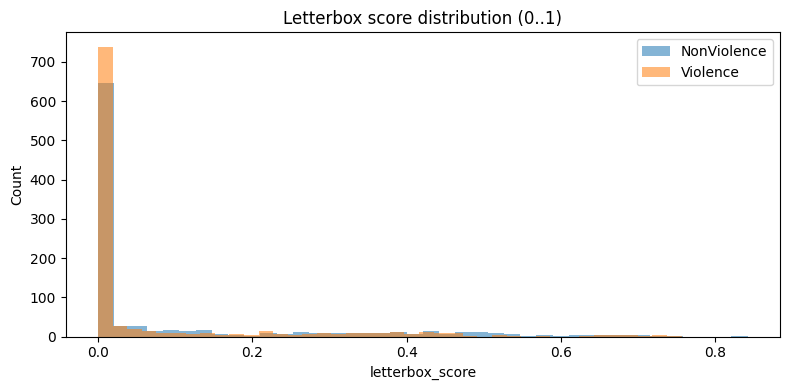

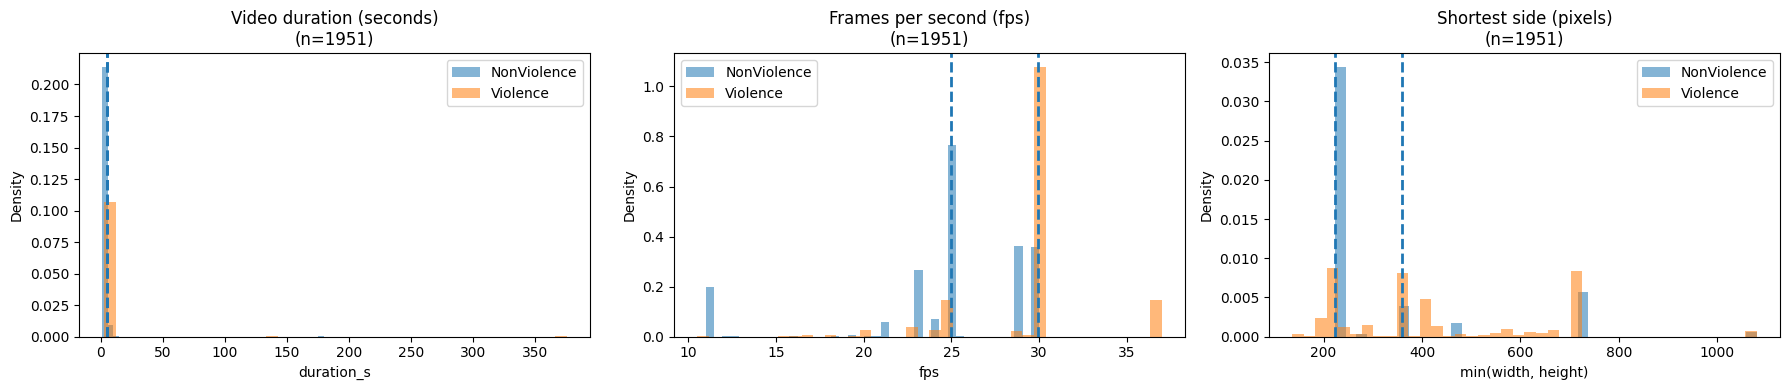

{'recommended_input_size': 224,
 'recommended_sampling_T': 24,
 'crop_strategy': 'Resize shorter side -> center crop',
 'median_duration_s': 5.0,
 'p25_p75_duration_s': (4.807, 5.0),
 'median_fps': 29.474,
 'p25_p75_fps': (25.0, 30.0),
 'median_min_side_px': 240.0,
 'p25_min_side_px': 224.0,
 'aspect_std': 0.4222319774035934,
 'letterbox_note': 'Letterboxing does not appear to be dominant.'}

In [6]:
# -----------------------------
# DATASET SNAPSHOT + RECOMMENDER
# -----------------------------

import os, json, subprocess, math
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

# ==========
# CONFIG
# ==========
BASE = DATASET_ROOT
CLASS_DIRS = {
    "Violence": 1,
    "NonViolence": 0
}

# Try less videos first to estimate runtime, use None if you want all
MAX_VIDEOS_PER_CLASS = None

# Letterbox-Check: every video could take longer
LETTERBOX_SAMPLE_PER_CLASS = 1000

#save high likelyhood letterbox videos
LB_SAVE_THRESHOLD = 0.35  # 0.35 = borders are around 50% darker then the middle
LB_SAVE_TOPK = 200
LB_SAVE_CSV = "letterbox_high_score_videos.csv"


# ==========
# FFPROBE
# ==========

# function to check video metadata
def _run_ffprobe(path: str) -> dict:
    cmd = [
        "ffprobe", "-v", "error",
        "-print_format", "json",
        "-show_format",
        "-show_streams",
        path
    ]
    out = subprocess.check_output(cmd).decode("utf-8")
    return json.loads(out)

# fucntion to transform fps values from ratios 3000/1000 to a decimal
def _parse_fps(fr_str):
    if not fr_str or fr_str == "0/0":
        return None
    try:
        num, den = fr_str.split("/")
        den = float(den)
        return float(num) / den if den != 0 else None
    except:
        return None

# full video probe
def probe_video(path: str) -> dict:
    # check the data streams, like video, audio, subtitles and filter only videos
    info = _run_ffprobe(path)
    fmt = info.get("format", {})
    streams = info.get("streams", [])
    vstreams = [s for s in streams if s.get("codec_type") == "video"]
    v = vstreams[0] if vstreams else {}

    # check filesize(Bit), duration(s) and bitrate(bit/s)
    size_bytes = os.path.getsize(path) if os.path.exists(path) else None
    duration = float(fmt["duration"]) if "duration" in fmt else None
    bitrate = int(fmt["bit_rate"]) if "bit_rate" in fmt else None

    # check framerate(frames/s) and width and heigth
    fps = _parse_fps(v.get("avg_frame_rate")) or _parse_fps(v.get("r_frame_rate"))
    width = int(v["width"]) if "width" in v else None
    height = int(v["height"]) if "height" in v else None

    # check amount of frames, estimate as fallback
    nb_frames = None
    if "nb_frames" in v:
        try:
            nb_frames = int(v["nb_frames"])
        except:
            nb_frames = None
    if nb_frames is None and duration is not None and fps is not None:
        nb_frames = int(round(duration * fps))

    # calculate aspect ratio
    aspect = None
    if width and height and height != 0:
        aspect = width / height

    return {
        "path": path,
        "file_size_mb": (size_bytes / (1024**2)) if size_bytes else None,
        "duration_s": duration,
        "fps": fps,
        "n_frames": nb_frames,
        "width": width,
        "height": height,
        "aspect": aspect,
        "codec": v.get("codec_name"),
        "pix_fmt": v.get("pix_fmt"),
        "bitrate_kbps": (bitrate / 1000) if bitrate else None,
        "container": fmt.get("format_name"),
    }

# ==========
# QUICK LETTERBOX / BLACK BAR CHECK (heuristic)
# ==========

# function to check if videos have black bars
def letterbox_score_fast(path: str, num_frames=6, border_frac=0.08):
    try:
        import decord
        from decord import VideoReader, cpu
    except Exception:
        return None

    try:
        # read video and sample frames
        vr = VideoReader(path, ctx=cpu(0))
        n = len(vr)
        if n <= 0:
            return None
        idxs = np.linspace(0, n-1, num_frames).astype(np.int64)

        #get frames in format (T,H,W,RGB)
        frames = vr.get_batch(idxs)
        # decord NDArray -> numpy
        if hasattr(frames, "asnumpy"):
              frames = frames.asnumpy()
        fr = frames.astype(np.float32)

        # turn pixel values from (R,G,B) to luminance skalar. Use established formula that weighs RGB correctly
        # we use luminance becuase through compression etc. it is not always perfectly black
        lum = 0.2126*fr[...,0] + 0.7152*fr[...,1] + 0.0722*fr[...,2]

        # use height and width of the frames to define borders
        T, H, W = lum.shape
        bh = max(1, int(H * border_frac))
        bw = max(1, int(W * border_frac))

        top = lum[:, :bh, :].mean(axis=(1,2))
        bottom = lum[:, -bh:, :].mean(axis=(1,2))
        left = lum[:, :, :bw].mean(axis=(1,2))
        right = lum[:, :, -bw:].mean(axis=(1,2))
        center = lum[:, bh:-bh, bw:-bw].mean(axis=(1,2))

        border = np.stack([top, bottom, left, right], axis=1).mean(axis=1)

        #create a ratio of border luminance to center luminance. The smaller the ratio the higher the likelyhood of letterbox
        ratio = border / (center + 1e-6)

        # turn ratio into a fixed score between 0 and 1 and one is letterbox instead of small number
        # Use 75% avg luminace of borders as baseline
        score = np.clip((0.75 - ratio) / 0.75, 0, 1)
        return float(np.mean(score))
    except:
        return None


# ==========
# COLLECT METADATA
# ==========

#find all exact paths in folder
def collect_paths():
    all_rows = []
    for folder, label in CLASS_DIRS.items():
        p = BASE / folder
        if not p.exists():
            print(f"[WARN] Missing folder: {p}")
            continue
        vids = list(p.rglob("*.mp4"))
        if MAX_VIDEOS_PER_CLASS is not None:
            vids = vids[:MAX_VIDEOS_PER_CLASS]
        for v in vids:
            all_rows.append({"path": str(v), "label": label, "cls": folder})  #cls stand for class, violence/nonviolence
    return pd.DataFrame(all_rows)

df_paths = collect_paths()
print("Found videos:", len(df_paths))
print(df_paths["cls"].value_counts(dropna=False))


# apply metadata functions in a loop
rows = []
for r in tqdm(df_paths.itertuples(index=False), total=len(df_paths)):
    try:
        m = probe_video(r.path)
        m["label"] = r.label
        m["cls"] = r.cls
        rows.append(m)
    except Exception as e:
        rows.append({"path": r.path, "label": r.label, "cls": r.cls, "error": str(e)})

df = pd.DataFrame(rows)
df_ok = df[df["error"].isna()].copy() if "error" in df.columns else df.copy()

print("\nParsed OK:", len(df_ok), "Errors:", len(df) - len(df_ok))

# ==========
# SUMMARIES
# ==========

# define quantiles for statistics
def quantiles(s, qs=(0.05, 0.25, 0.5, 0.75, 0.95)):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return {}
    q = s.quantile(qs).to_dict()
    return {f"q{int(k*100):02d}": float(v) for k, v in q.items()}


# create a qunatile table
def basic_summary(df_ok):
    out = {}
    for col in ["file_size_mb","duration_s","fps","n_frames","width","height","aspect","bitrate_kbps"]:
        out[col] = quantiles(df_ok[col])
    return pd.DataFrame(out).T

summary = basic_summary(df_ok)
summary

# Most common resolutions based on count
df_ok["resolution"] = df_ok.apply(lambda x: f"{int(x.width)}x{int(x.height)}" if pd.notna(x.width) and pd.notna(x.height) else None, axis=1)
top_res = df_ok["resolution"].value_counts().head(15)


# Aspect ratio buckets. Turn the aspect ratios into common formats. To decide how to crop
def ar_bucket(a):
    if pd.isna(a): return None
    # common buckets
    if abs(a - (16/9)) < 0.08: return "≈16:9"
    if abs(a - (4/3)) < 0.08: return "≈4:3"
    if a > 2.0: return "wide (>2.0)"
    if a < 1.2: return "tall/near-square (<1.2)"
    return "other"

df_ok["aspect_bucket"] = df_ok["aspect"].apply(ar_bucket)
ar_counts = df_ok["aspect_bucket"].value_counts()

print("\nTop resolutions:\n", top_res)
print("\nAspect buckets:\n", ar_counts)


# ==========
# OPTIONAL: Letterbox check
# ==========
try:
    import decord  # just to see if installed
except:
    decord = None

# sample vidos and calculate letterbox scores
letterbox_stats = None
df_lb = None
if decord is not None:
    # sample a subset
    df_lb = df_ok.groupby("cls", group_keys=False).apply(lambda x: x.sample(min(len(x), LETTERBOX_SAMPLE_PER_CLASS), random_state=42))
    tqdm.pandas()
    df_lb = df_lb.copy()
    df_lb["letterbox_score"] = df_lb["path"].progress_apply(lambda p: letterbox_score_fast(p))
    letterbox_stats = df_lb["letterbox_score"].dropna().describe()
    print("\nLetterbox score (0..1) summary:\n", letterbox_stats)

    # save high-letterbox videos for manual inspection
    df_high_lb = (
        df_lb.dropna(subset=["letterbox_score"])
            .loc[df_lb["letterbox_score"] >= LB_SAVE_THRESHOLD, ["path", "cls", "letterbox_score"]]
            .sort_values("letterbox_score", ascending=False)
            .head(LB_SAVE_TOPK)
            .copy()
    )
    df_high_lb.to_csv(LB_SAVE_CSV, index=False)
    print(f"\nSaved high-letterbox video list: {LB_SAVE_CSV} (n={len(df_high_lb)})")
    print(df_high_lb.head(10))

    # letterbox histogram
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,4))
    for cls_name, g in df_lb.dropna(subset=["letterbox_score"]).groupby("cls"):
        plt.hist(g["letterbox_score"].values, bins=40, alpha=0.55, label=str(cls_name))
    plt.title("Letterbox score distribution (0..1)")
    plt.xlabel("letterbox_score")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("\n[INFO] decord not installed -> skipping letterbox check. Install via: !pip -q install decord")


# =====================
# Key values histograms
# =====================

def plot_video_distributions(df_ok, bins=40):
    """
    Plots distributions for:
      1) video duration (seconds)
      2) fps
      3) shortest side (min(width, height))
    df_ok: dataframe with columns duration_s, fps, width, height
    bins: number of histogram bins
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # --- helper to coerce numeric safely ---
    def _num(s):
        return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

    # shortest side: align indices first (width/height might have missing in different rows)
    wh = pd.concat([pd.to_numeric(df_ok.get("width"), errors="coerce"),
                    pd.to_numeric(df_ok.get("height"), errors="coerce")], axis=1)
    wh.columns = ["width", "height"]
    min_side_all = wh.min(axis=1).replace([np.inf, -np.inf], np.nan)

    # --- plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    plots = [
        ("duration_s", "Video duration (seconds)", "duration_s"),
        ("fps", "Frames per second (fps)", "fps"),
        ("min_side", "Shortest side (pixels)", "min(width, height)"),
    ]

    # precompute per-class series
    df_tmp = df_ok.copy()
    df_tmp["min_side"] = min_side_all

    for ax, (col, title, xlabel) in zip(axes, plots):
        if col not in df_tmp.columns:
            ax.set_title(title + "\n(no valid values)")
            ax.axis("off")
            continue

        any_data = False
        for cls_name, g in df_tmp.groupby("cls"):
            data = _num(g[col])
            if len(data) == 0:
                continue
            any_data = True
            ax.hist(data, bins=bins, density=True, alpha=0.55, label=str(cls_name))
            ax.axvline(data.median(), linewidth=2, linestyle="--")

        if not any_data:
            ax.set_title(title + "\n(no valid values)")
            ax.axis("off")
            continue

        ax.set_title(f"{title}\n(n={df_tmp[col].notna().sum()})")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Return computed series in case you want to reuse
    return {
        "duration_s": _num(df_tmp.get("duration_s")),
        "fps": _num(df_tmp.get("fps")),
        "min_side": _num(df_tmp.get("min_side")),
    }



plot_video_distributions(df_ok, bins=40)


# ==========
# RECOMMENDATIONS
# ==========
def recommend(df_ok, letterbox_stats=None):
    # Core stats
    dur = pd.to_numeric(df_ok["duration_s"], errors="coerce").dropna()
    fps = pd.to_numeric(df_ok["fps"], errors="coerce").dropna()
    h = pd.to_numeric(df_ok["height"], errors="coerce").dropna()
    w = pd.to_numeric(df_ok["width"], errors="coerce").dropna()

    dur_med = float(dur.median()) if len(dur) else None
    dur_p25 = float(dur.quantile(0.25)) if len(dur) else None
    dur_p75 = float(dur.quantile(0.75)) if len(dur) else None

    fps_med = float(fps.median()) if len(fps) else None
    fps_p25 = float(fps.quantile(0.25)) if len(fps) else None
    fps_p75 = float(fps.quantile(0.75)) if len(fps) else None

    # check minima to know the minimum size we can crop
    min_side_med = float(pd.concat([h,w], axis=1).min(axis=1).median()) if len(h) and len(w) else None
    min_side_p25 = float(pd.concat([h,w], axis=1).min(axis=1).quantile(0.25)) if len(h) and len(w) else None


    # Decide input size
    # If many videos have min_side below ~160-180, 224 can be too aggressive -> 112/160 is safer.
    input_size = 224
    if min_side_p25 is not None and min_side_p25 < 180:
        input_size = 112  # more robust for low-res
    elif min_side_p25 is not None and min_side_p25 < 220:
        input_size = 160  # compromise (often works well)


    # Cropping strategy
    # If aspect ratios vary a lot, center-crop after resize-to-shorter-side is safest.
    ar_var = float(pd.to_numeric(df_ok["aspect"], errors="coerce").dropna().std()) if df_ok["aspect"].notna().any() else None
    use_crop = True if (ar_var is None or ar_var > 0.25) else False

    crop_note = "Resize shorter side -> center crop" if use_crop else "Simple resize (no crop) might work"


    # Sampling T:
    # Use median duration and fps to see how many frames exist.
    # longer videos -> more frames to capture everything
    # Heuristic:
    # - if median duration <= 2.5s => T=16 is fine
    # - if 2.5-6s => T=24
    # - if >6s => T=32 (or 16 with larger temporal stride)
    T = 16
    if dur_med is not None:
        if dur_med > 6:
            T = 32
        elif dur_med > 2.5:
            T = 24
        else:
            T = 16

    # If fps is low or many clips short, reduce T
    if dur_p25 is not None and dur_p25 < 1.8:
        T = min(T, 16)

    # Letterbox
    lb_text = None
    if letterbox_stats is not None:
        mean_lb = float(letterbox_stats.get("mean", np.nan))
        if not math.isnan(mean_lb):
            if mean_lb > 0.35:
                lb_text = "Many videos appear to be letterboxed (black bars)."
            else:
                lb_text = "Letterboxing does not appear to be dominant."

    rec = {
        "recommended_input_size": input_size,
        "recommended_sampling_T": T,
        "crop_strategy": crop_note,
        "median_duration_s": dur_med,
        "p25_p75_duration_s": (dur_p25, dur_p75),
        "median_fps": fps_med,
        "p25_p75_fps": (fps_p25, fps_p75),
        "median_min_side_px": min_side_med,
        "p25_min_side_px": min_side_p25,
        "aspect_std": ar_var,
        "letterbox_note": lb_text
    }
    return rec

rec = recommend(df_ok, letterbox_stats=letterbox_stats)
rec

## 2.2 check video with least frames, to avoid duplicate sampling for a single clip

In [7]:
# find video with the least total frames
df_nf = df_ok.dropna(subset=["n_frames"]).copy()
df_nf["n_frames"] = df_nf["n_frames"].astype(int)

min_row = df_nf.loc[df_nf["n_frames"].idxmin()]

print("Video with fewest frames:")
print("Path:", min_row["path"])
print("Class:", min_row["cls"])
print("Total frames:", min_row["n_frames"])


Video with fewest frames:
Path: /content/drive/MyDrive/Advanced Analytics/kaglle_violence (Unzipped Files)/Real Life Violence Dataset/NonViolence/NV_940.mp4
Class: NonViolence
Total frames: 29


## 2.3 Check duration distribution of videos not visible in histogram

In [8]:
import numpy as np
import pandas as pd

# ----------------------------
# TABLE: duration bins (1s) x class counts
# ----------------------------

# 1) Use df_ok explicitly
df_tmp = df_ok.copy()

# 2) Clean
df_tmp["duration_s"] = pd.to_numeric(df_tmp["duration_s"], errors="coerce")
df_tmp = df_tmp.dropna(subset=["duration_s", "cls"]).copy()

# 3) Build 1-second bins: [0–1), [1–2), ... up to max
max_dur = float(df_tmp["duration_s"].max())
max_edge = int(np.ceil(max_dur))
bins = np.arange(0, max_edge + 1, 1)

df_tmp["dur_bin"] = pd.cut(
    df_tmp["duration_s"],
    bins=bins,
    right=False,          # [a,b)
    include_lowest=True
)

# 4) Count per bin per class
tab = (
    df_tmp.groupby(["dur_bin", "cls"])
          .size()
          .unstack(fill_value=0)
          .reset_index()
)

# 5) Friendly labels like "0–1", "1–2", ...
def _label(interval):
    return f"{int(interval.left)}–{int(interval.right)}" if pd.notna(interval) else None

tab.insert(0, "duration_range_s", tab["dur_bin"].apply(_label))
tab = tab.drop(columns=["dur_bin"])

# Ensure both columns exist
for col in ["Violence", "NonViolence"]:
    if col not in tab.columns:
        tab[col] = 0

tab["Total"] = tab["Violence"] + tab["NonViolence"]

# 6) Keep only non-empty bins
tab = tab[tab["Total"] > 0].copy()

# Sort by bin start
tab["_left"] = tab["duration_range_s"].str.split("–").str[0].astype(int)
tab = tab.sort_values("_left").drop(columns=["_left"]).reset_index(drop=True)

print(f"Max duration: {max_dur:.2f}s | bins: {len(tab)} rows")
tab


Max duration: 375.75s | bins: 12 rows


/tmp/ipykernel_795/538905169.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tmp.groupby(["dur_bin", "cls"])


cls,duration_range_s,NonViolence,Violence,Total
0,1–2,1,0,1
1,2–3,4,1,5
2,3–4,30,78,108
3,4–5,132,297,429
4,5–6,764,586,1350
5,6–7,16,28,44
6,7–8,2,7,9
7,10–11,1,0,1
8,11–12,0,1,1
9,136–137,0,1,1


## 2.4 Remove Outlier Videos

In [9]:
MAX_DUR_S = 8.0  # Set Max duration to 8 seconds

# df_ok must contain: duration_s, cls, label, path (at least duration_s)
df_ok["duration_s"] = pd.to_numeric(df_ok["duration_s"], errors="coerce")

# keep only videos with valid duration and <= 8s
df_ok_filt = df_ok.dropna(subset=["duration_s"]).query("duration_s <= @MAX_DUR_S").copy()

# (optional) see what got removed
df_outliers = df_ok.dropna(subset=["duration_s"]).query("duration_s > @MAX_DUR_S")[["path","cls","duration_s"]].sort_values("duration_s")

print("Before:", len(df_ok))
print("After :", len(df_ok_filt))
print("Removed:", len(df_ok) - len(df_ok_filt))
print("\nOutliers removed:")
print(df_outliers.to_string(index=False))


Before: 1951
After : 1946
Removed: 5

Outliers removed:
                                                                                                                        path         cls  duration_s
/content/drive/MyDrive/Advanced Analytics/kaglle_violence (Unzipped Files)/Real Life Violence Dataset/NonViolence/NV_363.mp4 NonViolence   10.261000
    /content/drive/MyDrive/Advanced Analytics/kaglle_violence (Unzipped Files)/Real Life Violence Dataset/Violence/V_377.mp4    Violence   11.320000
    /content/drive/MyDrive/Advanced Analytics/kaglle_violence (Unzipped Files)/Real Life Violence Dataset/Violence/V_398.mp4    Violence  136.974479
/content/drive/MyDrive/Advanced Analytics/kaglle_violence (Unzipped Files)/Real Life Violence Dataset/NonViolence/NV_992.mp4 NonViolence  179.908203
    /content/drive/MyDrive/Advanced Analytics/kaglle_violence (Unzipped Files)/Real Life Violence Dataset/Violence/V_789.mp4    Violence  375.745247


## 2.5 Train/Val/Test - Split

In [10]:
from sklearn.model_selection import train_test_split

# 1. Fix random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 2. Create dataset split (70% Train, 15% Validation, 15% Test)
# We use df_ok_filt because it only contains videos that were successfully loaded
# and have valid sequence lengths
train_df, temp_df = train_test_split(
    df_ok_filt,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df_ok_filt['label']  # Important: Maintain the same Violence/Non-Violence distribution across all sets
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df['label']
)

# 3. Define output directory for saving the splits
# We use the "Advanced Analytics" folder in Google Drive
output_path = SPLITS_DIR
if not os.path.exists(output_path):
    os.makedirs(output_path)

# 4. Save as CSV
train_df.to_csv(TRAIN_SPLIT_CSV, index=False)
val_df.to_csv(VAL_SPLIT_CSV, index=False)
test_df.to_csv(TEST_SPLIT_CSV, index=False)

print(f"--- Split erfolgreich abgeschlossen ---")
print(f"Train: {len(train_df)} Videos")
print(f"Val:   {len(val_df)} Videos")
print(f"Test:  {len(test_df)} Videos")
print(f"Dateien wurden in {output_path} gespeichert.")

--- Split erfolgreich abgeschlossen ---
Train: 1362 Videos
Val:   292 Videos
Test:  292 Videos
Dateien wurden in /content/drive/MyDrive/Advanced Analytics gespeichert.


# Frame Sampling

## V1: Random Side reflective Padding

For efficiency you would ideally directly embedd the pictures, but we want to take a look at the transformations, thus we save them.

In [ ]:
import os, re, subprocess, traceback, shutil, hashlib
from pathlib import Path
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool, cpu_count, current_process
from PIL import Image

# ----------------------------
# CONFIG
# ----------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FPS = 5
TARGET = 224

BASE_OUT = FRAMES_PAD_DIR
BASE_OUT.mkdir(parents=True, exist_ok=True)

MIN_FRAMES_TO_CONSIDER_DONE = 1


DEBUG = True

# Print detailed logs for every single video
DEBUG_EVERY_VIDEO = True

# If True: keep temp extracted frames for debugging (warning: huge)
KEEP_TEMP = False


def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# Convert path to string and remove leading/trailing whitespace from csv row function
def _clean_path(p) -> str:
    return str(p).strip()


def _safe_stem(p: str) -> str:
    # Extract filename without extension
    stem = Path(p).stem
    # Replace all non-safe characters with underscores
    stem = re.sub(r"[^A-Za-z0-9._-]+", "_", stem).strip("_")
    # Limit length to avoid OS filename limits
    return stem[:140]


# ============================================
# RANDOMNESS PER VIDEO
# ============================================

def _rng_for_video(video_path: str) -> np.random.Generator:
    # deterministic per video path (stable across reruns)
    seed = abs(hash((video_path, RANDOM_SEED))) % (2**32)
    return np.random.default_rng(seed)

# ============================================
# NAMING + STATUS HELPERS
# ============================================

def _prefix(video_path: str, split: str) -> str:
    # assumes filename stem is unique across dataset
    return f"{_safe_stem(video_path)}_{split}"


# check if video is already in the folder
def _already_done(video_path: str, split: str, out_dir: Path) -> bool:
    # Check if frames already exist for this video
    pref = _prefix(video_path, split)
    # Count how many frame files match this prefix
    cnt = len(list(out_dir.glob(f"{pref}_frame_*.jpg")))
    return cnt >= MIN_FRAMES_TO_CONSIDER_DONE


# ============================================
# TEMP DIRECTORY HANDLING
# ============================================

def _tmp_dir_for_video(video_path: str) -> Path:
    # Unique temp dir per video + process, avoids collisions in multiprocessing
    pid = os.getpid()
    # Hash the video path
    h = hashlib.md5(video_path.encode("utf-8")).hexdigest()[:10]
    d = Path("/tmp") / f"tmp_frames_{pid}_{h}"
    d.mkdir(parents=True, exist_ok=True)
    return d


# ============================================
# IMAGE PADDING FUNCTION
# ============================================

def _pad_reflect_to_square(img_np: np.ndarray, top_frac: float, left_frac: float, target: int = 224) -> np.ndarray:
    """
    img_np: H x W x C (uint8)
    Pads to target x target using reflect padding.
    Padding placement is randomized by fractions (top/left).
    """
    h, w = img_np.shape[:2]
    pad_h = max(0, target - h)
    pad_w = max(0, target - w)

    # Randomly place padding at top/left
    top = int(np.trunc(pad_h * top_frac))
    left = int(np.trunc(pad_w * left_frac))

    # Remaining padding goes to bottom/right
    bottom = pad_h - top
    right = pad_w - left

    # Already square and correct size
    if pad_h == 0 and pad_w == 0:
        return img_np

    # Padding format for NumPy: (height padding), (width padding), (channel padding)
    pad_spec = ((top, bottom), (left, right), (0, 0))

    # Try reflect padding first
    # If padding is larger than image size, fallback to edge padding
    try:
        return np.pad(img_np, pad_spec, mode="reflect")
    except ValueError:
        return np.pad(img_np, pad_spec, mode="edge")

# ============================================
# MAIN WORKER FUNCTION
# ============================================

def extract_frames_one(args: tuple) -> tuple:
    video_path, split, out_dir = args
    pid = os.getpid()
    pname = current_process().name

    tmp_dir = None

    try:
        # Debug Header
        if DEBUG_EVERY_VIDEO:
            _log(f"\n[{pname} pid={pid}] START split={split}")
            _log(f"[{pname} pid={pid}] 1) video_path = {video_path}")
            _log(f"[{pname} pid={pid}] 2) out_dir   = {out_dir}")

        # Step A: Check if the Video was already done
        pref = _prefix(video_path, split)
        existing = len(list(out_dir.glob(f"{pref}_frame_*.jpg")))
        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 3) prefix   = {pref}")
            _log(f"[{pname} pid={pid}] 4) existing frames matching prefix = {existing}")

        # skip if the videos is in the folder
        if existing >= MIN_FRAMES_TO_CONSIDER_DONE:
            if DEBUG_EVERY_VIDEO:
                _log(f"[{pname} pid={pid}] -> SKIP (already_done)")
            return (video_path, split, True, "skipped_already_done")

        # Step B: input exists?
        vp = Path(video_path)
        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 5) checking exists(): {vp}")

        if not vp.exists():
            _log(f"[{pname} pid={pid}] !!! MISSING FILE: {vp}")
            return (video_path, split, False, "missing")

        # Step C: RNG + padding placement (deterministic per video)
        rng = _rng_for_video(video_path)
        top_frac = float(rng.random())
        left_frac = float(rng.random())
        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 6) padding fractions: top={top_frac:.6f}, left={left_frac:.6f}")

        # Step D: Extract scaled frames to TEMP (no padding in ffmpeg)
        tmp_dir = _tmp_dir_for_video(video_path)
        # Output pattern for ffmpeg
        tmp_pattern = str(tmp_dir / "raw_%06d.jpg")

        vf_ffmpeg = (
            f"fps={FPS},"
            f"scale='if(gte(iw,ih),{TARGET},-2)':'if(gte(iw,ih),-2,{TARGET})'" # - scale -> resize so the SHORT side becomes TARGET
        )

        cmd = [
            "ffmpeg", "-hide_banner", "-loglevel", "error",
            "-i", str(vp),
            "-vf", vf_ffmpeg,
            "-q:v", "2",
            tmp_pattern
        ]

        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 7) ffmpeg vf (no pad) = {vf_ffmpeg}")
            _log(f"[{pname} pid={pid}] 8) tmp_pattern = {tmp_pattern}")
            _log(f"[{pname} pid={pid}] 9) running ffmpeg cmd:")
            _log(f"[{pname} pid={pid}]    {' '.join(cmd)}")

        res = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

        if res.returncode != 0:
            # ffmpeg failed
            _log(f"[{pname} pid={pid}] !!! FFMPEG ERROR returncode={res.returncode}")

            if res.stderr:
                _log(f"[{pname} pid={pid}] --- ffmpeg stderr ---\n{res.stderr}\n--- end stderr ---")
            return (video_path, split, False, "ffmpeg_error")

        raw_frames = sorted(tmp_dir.glob("raw_*.jpg"))

        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 10) raw frames extracted = {len(raw_frames)}")

        if len(raw_frames) == 0:
            _log(f"[{pname} pid={pid}] !!! NO RAW FRAMES EXTRACTED")
            return (video_path, split, False, "no_raw_frames")

        # Step E: Pad in Python (reflect) and save final frames
        # Output naming: <pref>_frame_<n>.jpg (start at 1)
        saved = 0

        for i, f in enumerate(raw_frames, start=1):
            # Load raw frame
            img = Image.open(f).convert("RGB")
            arr = np.array(img)  # Convert to NumPy array (H, W, 3)

            # Pad to TARGET x TARGET
            padded = _pad_reflect_to_square(arr, top_frac=top_frac, left_frac=left_frac, target=TARGET)
            out_path = out_dir / f"{pref}_frame_{i}.jpg"

            Image.fromarray(padded).save(out_path, quality=95)
            saved += 1

        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 11) saved final frames = {saved}")

        if saved == 0:
            _log(f"[{pname} pid={pid}] !!! NO FRAMES SAVED AFTER PADDING")
            return (video_path, split, False, "no_frames_saved")

        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] DONE OK")

        return (video_path, split, True, pref)

    except Exception as e:
        # Catch any unexpected crash
        _log(f"[{pname} pid={pid}] !!! EXCEPTION: {repr(e)}")
        _log(traceback.format_exc())
        return (video_path, split, False, "exception")

    finally:
        # Cleanup temp frames
        if tmp_dir is not None and tmp_dir.exists() and not KEEP_TEMP:
            try:
                # Delete temp directory
                shutil.rmtree(tmp_dir, ignore_errors=True)
            except Exception:
                pass

# ----------------------------
# VERIFY SPLITS
# ----------------------------
_log("VERIFY SPLITS: checking train_df / val_df / test_df exist and contain 'path'...")

for name in ["train_df", "val_df", "test_df"]:
    # Make sure DataFrames exist
    if name not in globals():
        raise NameError(f"{name} not found. Please run your split creation first.")

    # Make sure they contain a 'path' column
    if "path" not in globals()[name].columns:
        raise ValueError(f"{name} must contain a 'path' column.")

    # Clean and normalize paths
    globals()[name]["path"] = globals()[name]["path"].astype(str).map(_clean_path)


# ============================================
# SPLIT REGISTRATION
# ============================================

SPLITS = {"train": train_df, "val": val_df, "test": test_df}


# ============================================
# OUTPUT DIRECTORIES
# ============================================

# Create subfolders for each split
OUT_DIRS = {}
_log(f"Creating output dirs under: {BASE_OUT}")
for split in SPLITS.keys():
    d = BASE_OUT / split
    d.mkdir(parents=True, exist_ok=True)
    OUT_DIRS[split] = d
    _log(f" - {split}: {d}")

# ----------------------------
# BUILD JOB LIST
# ----------------------------
_log("BUILD JOB LIST: checking already-done status...")
jobs_all, jobs_todo = [], []

for split_name, df_split in SPLITS.items():
    out_dir = OUT_DIRS[split_name]
    for p in df_split["path"].astype(str).tolist():
        job = (p, split_name, out_dir)
        jobs_all.append(job)
        if not _already_done(p, split_name, out_dir):
            jobs_todo.append(job)

print(f"\nTotal videos in splits: {len(jobs_all)}")
print(f"Videos still to process (resume-safe): {len(jobs_todo)}")

print("\nSample input paths (first 5):")
for j in jobs_all[:5]:
    print(" -", j[0])

# ----------------------------
# RUN (parallel)
# ----------------------------
if len(jobs_todo) == 0:
    print("\nNothing to do — all videos appear to be processed already.")
else:
    workers = min(8, max(2, cpu_count() // 2))
    print(f"\nRunning with workers={workers}")

    results = []
    with Pool(processes=workers) as pool:
        for r in tqdm(pool.imap_unordered(extract_frames_one, jobs_todo), total=len(jobs_todo)):
            results.append(r)

    # Summarize results
    ok = sum(1 for _, _, success, _ in results if success)
    bad = len(results) - ok
    skipped = sum(1 for _, _, success, msg in results if success and msg == "skipped_already_done")

    print(f"\nDone. Success: {ok} | Failed: {bad} | Skipped: {skipped}")
    print(f"Frames saved under: {BASE_OUT}")

    failures = [(p, split, msg) for (p, split, success, msg) in results if not success]
    if failures:
        print("\nSome failures (first 50):")
        for p, split, msg in failures[:50]:
            print(f"[{split}] {msg} -> {p}")


VERIFY SPLITS: checking train_df / val_df / test_df exist and contain 'path'...
Creating output dirs under: /content/drive/MyDrive/Advanced Analytics/frames
 - train: /content/drive/MyDrive/Advanced Analytics/frames/train
 - val: /content/drive/MyDrive/Advanced Analytics/frames/val
 - test: /content/drive/MyDrive/Advanced Analytics/frames/test
BUILD JOB LIST: checking already-done status...


## Analyse fill balance

In [ ]:
import re
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

BASE_DIR = FRAMES_PAD_DIR
TARGET = 224

# reflect detection params
MAX_PAD = 112
THRESH = 6
MIN_W  = 2

assert BASE_DIR.exists()

# ----------------------------
# helpers
# ----------------------------
def to_gray(arr):
    return (0.2126*arr[...,0] + 0.7152*arr[...,1] + 0.0722*arr[...,2]).astype(np.float32)

def mad(a,b):
    return float(np.mean(np.abs(a-b)))

def est_left(g):
    H,W = g.shape; pad=0; max_w=min(MAX_PAD, W//2-1)
    for w in range(1, max_w+1):
        if mad(g[:, :w], g[:, w:2*w][:, ::-1]) <= THRESH:
            pad=w
        else:
            break
    return pad

def est_right(g):
    H,W = g.shape; pad=0; max_w=min(MAX_PAD, W//2-1)
    for w in range(1, max_w+1):
        if mad(g[:, W-w:W], g[:, W-2*w:W-w][:, ::-1]) <= THRESH:
            pad=w
        else:
            break
    return pad

def est_top(g):
    H,W = g.shape; pad=0; max_h=min(MAX_PAD, H//2-1)
    for h in range(1, max_h+1):
        if mad(g[:h, :], g[h:2*h, :][::-1, :]) <= THRESH:
            pad=h
        else:
            break
    return pad

def est_bottom(g):
    H,W = g.shape; pad=0; max_h=min(MAX_PAD, H//2-1)
    for h in range(1, max_h+1):
        if mad(g[H-h:H, :], g[H-2*h:H-h, :][::-1, :]) <= THRESH:
            pad=h
        else:
            break
    return pad

def add_heat(HM, T,L,B,R):
    if T>0: HM[:T,:]+=1
    if B>0: HM[-B:,:]+=1
    if L>0: HM[:,:L]+=1
    if R>0: HM[:,-R:]+=1

def cls_from_prefix(pref: str) -> str:
    return "NonViolence" if pref.startswith("NV_") else "Violence"

frame_re = re.compile(r"^(.*)_frame_(\d+)\.jpg$", re.IGNORECASE)

def scan_split(split_name: str):
    split_dir = BASE_DIR / split_name
    assert split_dir.exists(), f"Missing split dir: {split_dir}"

    all_frames = list(split_dir.glob("*.jpg"))

    # prefix -> list of (n, path)
    by_pref = defaultdict(list)
    for fp in all_frames:
        mm = frame_re.match(fp.name)
        if mm:
            by_pref[mm.group(1)].append((int(mm.group(2)), fp))

    # pick smallest frame index per video
    one_frame = {pref: sorted(lst, key=lambda x:x[0])[0][1] for pref, lst in by_pref.items()}
    prefixes = list(one_frame.keys())

    heat = {
        "Violence": np.zeros((TARGET,TARGET), dtype=np.int32),
        "NonViolence": np.zeros((TARGET,TARGET), dtype=np.int32),
    }
    count_total = {"Violence": 0, "NonViolence": 0}
    count_fill  = {"Violence": 0, "NonViolence": 0}

    print(f"\n--- Scanning split={split_name} | videos={len(prefixes)} | frames={len(all_frames)} ---")
    for pref in tqdm(prefixes, desc=f"{split_name}: reflect-padding scan"):
        cls = cls_from_prefix(pref)
        fp = one_frame[pref]

        arr = np.array(Image.open(fp).convert("RGB"))
        g = to_gray(arr)

        L,R,T,B = est_left(g), est_right(g), est_top(g), est_bottom(g)
        L = L if L>=MIN_W else 0
        R = R if R>=MIN_W else 0
        T = T if T>=MIN_W else 0
        B = B if B>=MIN_W else 0

        count_total[cls] += 1
        if (L+R+T+B) > 0:
            count_fill[cls] += 1
            add_heat(heat[cls], T,L,B,R)

    diff = heat["Violence"].astype(np.int32) - heat["NonViolence"].astype(np.int32)

    return {
        "split": split_name,
        "frames_n": len(all_frames),
        "videos_n": len(prefixes),
        "count_total": count_total,
        "count_fill": count_fill,
        "heat": heat,
        "diff": diff,
    }

# ----------------------------
# 1) Scan all splits first
# ----------------------------
results = {s: scan_split(s) for s in ["train", "val", "test"]}

# ----------------------------
# 2) Compute GLOBAL color scales (comparable across ALL splits)
# ----------------------------
global_heat_max = 0
global_diff_absmax = 0

for s in ["train", "val", "test"]:
    H = results[s]["heat"]
    D = results[s]["diff"]
    global_heat_max = max(global_heat_max, int(H["Violence"].max()), int(H["NonViolence"].max()))
    global_diff_absmax = max(global_diff_absmax, int(np.max(np.abs(D))))

print("\n==============================")
print("GLOBAL SCALES (all splits comparable)")
print(f"Heatmaps: vmin=0, vmax={global_heat_max}")
print(f"Diffmaps: vmin=-{global_diff_absmax}, vmax=+{global_diff_absmax}")
print("==============================\n")

# ----------------------------
# 3) Print summaries + plots with GLOBAL scales
# ----------------------------
for s in ["train", "val", "test"]:
    r = results[s]
    ct, cf = r["count_total"], r["count_fill"]

    print(f"==== {s.upper()} SUMMARY ====")
    print(f"Frames: {r['frames_n']} | Videos: {r['videos_n']}")
    for cls in ["Violence", "NonViolence"]:
        tot = ct[cls]
        fill = cf[cls]
        pct = (fill/tot*100.0) if tot else 0.0
        print(f"{cls}: fill={fill}/{tot} ({pct:.1f}%)")
    print()

    # bar plot
    plt.figure()
    plt.bar(["Violence","NonViolence"], [cf["Violence"], cf["NonViolence"]])
    plt.title(f"{s}: videos with detected reflect-fill (1 frame/video)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # heatmaps (GLOBAL scale)
    for cls in ["Violence", "NonViolence"]:
        plt.figure()
        plt.imshow(r["heat"][cls], vmin=0, vmax=global_heat_max)
        plt.title(f"{s}: fill location heatmap — {cls} (GLOBAL scale)")
        plt.colorbar(label="Frequency")
        plt.tight_layout()
        plt.show()

    # difference map (GLOBAL symmetric scale)
    plt.figure()
    plt.imshow(r["diff"], vmin=-global_diff_absmax, vmax=global_diff_absmax, cmap="seismic")
    plt.title(f"{s}: Difference Map — Violence − NonViolence (GLOBAL scale)")
    plt.colorbar(label="Frequency Difference")
    plt.xlabel("X (pixels)")
    plt.ylabel("Y (pixels)")
    plt.tight_layout()
    plt.show()


# ----------------------------
# 4) COMBINED (train + val + test)
# ----------------------------
all_heat = {
    "Violence": np.zeros((TARGET, TARGET), dtype=np.int32),
    "NonViolence": np.zeros((TARGET, TARGET), dtype=np.int32),
}
all_count_total = {"Violence": 0, "NonViolence": 0}
all_count_fill  = {"Violence": 0, "NonViolence": 0}
all_frames_n = 0
all_videos_n = 0

for s in ["train", "val", "test"]:
    r = results[s]
    all_frames_n += r["frames_n"]
    all_videos_n += r["videos_n"]

    for cls in ["Violence", "NonViolence"]:
        all_heat[cls] += r["heat"][cls]
        all_count_total[cls] += r["count_total"][cls]
        all_count_fill[cls]  += r["count_fill"][cls]

all_diff = all_heat["Violence"].astype(np.int32) - all_heat["NonViolence"].astype(np.int32)

print("\n==== ALL (train+val+test) SUMMARY ====")
print(f"Frames: {all_frames_n} | Videos: {all_videos_n}")
for cls in ["Violence", "NonViolence"]:
    tot = all_count_total[cls]
    fill = all_count_fill[cls]
    pct = (fill/tot*100.0) if tot else 0.0
    print(f"{cls}: fill={fill}/{tot} ({pct:.1f}%)")

# Use GLOBAL scales for perfect comparability with the split plots
# all_heat_vmax = global_heat_max
# all_diff_absmax = global_diff_absmax

# (Optional) If you prefer scales based on ALL only, uncomment:
all_heat_vmax = int(max(all_heat["Violence"].max(), all_heat["NonViolence"].max()))
all_diff_absmax = int(np.max(np.abs(all_diff)))

plt.figure()
plt.bar(["Violence", "NonViolence"], [all_count_fill["Violence"], all_count_fill["NonViolence"]])
plt.title("ALL (train+val+test): videos with detected reflect-fill (1 frame/video)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

for cls in ["Violence", "NonViolence"]:
    plt.figure()
    plt.imshow(all_heat[cls], vmin=0, vmax=all_heat_vmax)
    plt.title(f"ALL: fill location heatmap — {cls} (GLOBAL scale)")
    plt.colorbar(label="Frequency")
    plt.tight_layout()
    plt.show()

plt.figure()
plt.imshow(all_diff, vmin=-all_diff_absmax, vmax=all_diff_absmax, cmap="seismic")
plt.title("ALL: Difference Map — Violence − NonViolence (GLOBAL scale)")
plt.colorbar(label="Frequency Difference")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.tight_layout()
plt.show()


Problem: Although reflective fill, enables us to keep all the information. It creates a bias, because of the underlying videos aspect ratio

## V2: Random Crop

In [ ]:
import os, re, subprocess, traceback, shutil, hashlib
from pathlib import Path
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool, cpu_count, current_process
from PIL import Image

# ----------------------------
# CONFIG
# ----------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FPS = 5
TARGET = 224
RESIZE_SHORT = 256  # default short-side resize when larger; we also ensure short-side >= TARGET

BASE_OUT = FRAMES_CROP_DIR
BASE_OUT.mkdir(parents=True, exist_ok=True)

MIN_FRAMES_TO_CONSIDER_DONE = 1

DEBUG = True
DEBUG_EVERY_VIDEO = True
KEEP_TEMP = False

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def _clean_path(p) -> str:
    return str(p).strip()

def _safe_stem(p: str) -> str:
    stem = Path(p).stem
    stem = re.sub(r"[^A-Za-z0-9._-]+", "_", stem).strip("_")
    return stem[:140]

# ============================================
# RANDOMNESS PER VIDEO (deterministic)
# ============================================
def _rng_for_video(video_path: str) -> np.random.Generator:
    seed = abs(hash((video_path, RANDOM_SEED))) % (2**32)
    return np.random.default_rng(seed)

# ============================================
# NAMING + STATUS HELPERS
# ============================================
def _prefix(video_path: str, split: str) -> str:
    return f"{_safe_stem(video_path)}_{split}"

def _already_done(video_path: str, split: str, out_dir: Path) -> bool:
    pref = _prefix(video_path, split)
    cnt = len(list(out_dir.glob(f"{pref}_frame_*.jpg")))
    return cnt >= MIN_FRAMES_TO_CONSIDER_DONE

# ============================================
# TEMP DIRECTORY HANDLING
# ============================================
def _tmp_dir_for_video(video_path: str) -> Path:
    pid = os.getpid()
    h = hashlib.md5(video_path.encode("utf-8")).hexdigest()[:10]
    d = Path("/tmp") / f"tmp_frames_{pid}_{h}"
    d.mkdir(parents=True, exist_ok=True)
    return d

# ============================================
# CROP HELPERS
# ============================================
def _get_crop_params(h: int, w: int, rng: np.random.Generator, target: int = 224, mode: str = "random"):
    """
    Return (top, left) crop coords for a given frame size.
    mode: "random" or "center"
    """
    if h < target or w < target:
        return 0, 0
    max_top = h - target
    max_left = w - target
    if mode == "center":
        return max_top // 2, max_left // 2
    top = int(rng.integers(0, max_top + 1)) if max_top > 0 else 0
    left = int(rng.integers(0, max_left + 1)) if max_left > 0 else 0
    return top, left

# ============================================
# MAIN WORKER FUNCTION
# ============================================
def extract_frames_one(args: tuple) -> tuple:
    video_path, split, out_dir = args
    pid = os.getpid()
    pname = current_process().name

    tmp_dir = None

    try:
        if DEBUG_EVERY_VIDEO:
            _log(f"\n[{pname} pid={pid}] START split={split}")
            _log(f"[{pname} pid={pid}] 1) video_path = {video_path}")
            _log(f"[{pname} pid={pid}] 2) out_dir   = {out_dir}")

        # Step A: already done?
        pref = _prefix(video_path, split)
        existing = len(list(out_dir.glob(f"{pref}_frame_*.jpg")))
        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 3) prefix   = {pref}")
            _log(f"[{pname} pid={pid}] 4) existing frames matching prefix = {existing}")

        if existing >= MIN_FRAMES_TO_CONSIDER_DONE:
            if DEBUG_EVERY_VIDEO:
                _log(f"[{pname} pid={pid}] -> SKIP (already_done)")
            return (video_path, split, True, "skipped_already_done")

        # Step B: input exists?
        vp = Path(video_path)
        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 5) checking exists(): {vp}")

        if not vp.exists():
            _log(f"[{pname} pid={pid}] !!! MISSING FILE: {vp}")
            return (video_path, split, False, "missing")

        # Step C: deterministic RNG per video (for TRAIN random crop)
        rng = _rng_for_video(video_path)

        # Step D: Extract resized frames to TEMP (resize only in ffmpeg)
        tmp_dir = _tmp_dir_for_video(video_path)
        tmp_pattern = str(tmp_dir / "raw_%06d.jpg")

        # ---- RESIZE LOGIC (IMPORTANT) ----
        # We choose a "desired short side" that is:
        # - RESIZE_SHORT (256) if the video is large enough,
        # - but at least TARGET (224) if the video is small.
        #
        # In ffmpeg: use min(RESIZE_SHORT, short_side) to avoid upscaling above 256,
        # but max(TARGET, ...) to ensure we upscale small videos to at least 224.
        #
        # Implementation:
        #   desired = min(RESIZE_SHORT, max(TARGET, short_side))
        #
        # Then set short side to desired and keep aspect ratio.
        vf_ffmpeg = (
            f"fps={FPS},"
            f"scale="
            f"'if(gte(iw,ih),-2,min({RESIZE_SHORT},max({TARGET},ih)))'"
            f":"
            f"'if(gte(iw,ih),min({RESIZE_SHORT},max({TARGET},iw)),-2)'"
        )

        cmd = [
            "ffmpeg", "-hide_banner", "-loglevel", "error",
            "-i", str(vp),
            "-vf", vf_ffmpeg,
            "-q:v", "2",
            tmp_pattern
        ]

        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 6) ffmpeg vf (resize only) = {vf_ffmpeg}")
            _log(f"[{pname} pid={pid}] 7) tmp_pattern = {tmp_pattern}")
            _log(f"[{pname} pid={pid}] 8) running ffmpeg cmd:")
            _log(f"[{pname} pid={pid}]    {' '.join(cmd)}")

        res = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if res.returncode != 0:
            _log(f"[{pname} pid={pid}] !!! FFMPEG ERROR returncode={res.returncode}")
            if res.stderr:
                _log(f"[{pname} pid={pid}] --- ffmpeg stderr ---\n{res.stderr}\n--- end stderr ---")
            return (video_path, split, False, "ffmpeg_error")

        raw_frames = sorted(tmp_dir.glob("raw_*.jpg"))
        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 9) raw frames extracted = {len(raw_frames)}")

        if len(raw_frames) == 0:
            _log(f"[{pname} pid={pid}] !!! NO RAW FRAMES EXTRACTED")
            return (video_path, split, False, "no_raw_frames")

        # Step E: Determine crop window ONCE per video (consistent across frames)
        first_img = Image.open(raw_frames[0]).convert("RGB")
        first_arr = np.array(first_img)
        H0, W0 = first_arr.shape[:2]

        need_crop = not (H0 == TARGET and W0 == TARGET)

        crop_top, crop_left = 0, 0
        if need_crop:
            if split == "train":
                crop_top, crop_left = _get_crop_params(H0, W0, rng=rng, target=TARGET, mode="random")
            else:
                crop_top, crop_left = _get_crop_params(H0, W0, rng=rng, target=TARGET, mode="center")

        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 10) first frame size = {W0}x{H0} | need_crop={need_crop}")
            if need_crop:
                _log(f"[{pname} pid={pid}] 11) crop window (top,left)=({crop_top},{crop_left}) to {TARGET}x{TARGET} | mode={'random' if split=='train' else 'center'}")
            else:
                _log(f"[{pname} pid={pid}] 11) no crop needed (already {TARGET}x{TARGET})")

        saved = 0
        for i, f in enumerate(raw_frames, start=1):
            img = Image.open(f).convert("RGB")
            arr = np.array(img)

            if (not need_crop) and arr.shape[0] == TARGET and arr.shape[1] == TARGET:
                cropped = arr
            else:
                cropped = arr[crop_top:crop_top+TARGET, crop_left:crop_left+TARGET, :]

                # safety fallback (should be rare)
                if cropped.shape[0] != TARGET or cropped.shape[1] != TARGET:
                    h, w = arr.shape[:2]
                    top = max(0, (h - TARGET)//2)
                    left = max(0, (w - TARGET)//2)
                    cropped = arr[top:top+TARGET, left:left+TARGET, :]

            out_path = out_dir / f"{pref}_frame_{i}.jpg"
            Image.fromarray(cropped).save(out_path, quality=95)
            saved += 1

        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] 12) saved final frames = {saved}")

        if saved == 0:
            _log(f"[{pname} pid={pid}] !!! NO FRAMES SAVED AFTER CROPPING")
            return (video_path, split, False, "no_frames_saved")

        if DEBUG_EVERY_VIDEO:
            _log(f"[{pname} pid={pid}] DONE OK")

        return (video_path, split, True, pref)

    except Exception as e:
        _log(f"[{pname} pid={pid}] !!! EXCEPTION: {repr(e)}")
        _log(traceback.format_exc())
        return (video_path, split, False, "exception")

    finally:
        if tmp_dir is not None and tmp_dir.exists() and not KEEP_TEMP:
            try:
                shutil.rmtree(tmp_dir, ignore_errors=True)
            except Exception:
                pass

# ----------------------------
# VERIFY SPLITS
# ----------------------------
_log("VERIFY SPLITS: checking train_df / val_df / test_df exist and contain 'path'...")

for name in ["train_df", "val_df", "test_df"]:
    if name not in globals():
        raise NameError(f"{name} not found. Please run your split creation first.")
    if "path" not in globals()[name].columns:
        raise ValueError(f"{name} must contain a 'path' column.")
    globals()[name]["path"] = globals()[name]["path"].astype(str).map(_clean_path)

SPLITS = {"train": train_df, "val": val_df, "test": test_df}

# ----------------------------
# OUTPUT DIRECTORIES
# ----------------------------
OUT_DIRS = {}
_log(f"Creating output dirs under: {BASE_OUT}")
for split in SPLITS.keys():
    d = BASE_OUT / split
    d.mkdir(parents=True, exist_ok=True)
    OUT_DIRS[split] = d
    _log(f" - {split}: {d}")

# ----------------------------
# BUILD JOB LIST
# ----------------------------
_log("BUILD JOB LIST: checking already-done status...")
jobs_all, jobs_todo = [], []

for split_name, df_split in SPLITS.items():
    out_dir = OUT_DIRS[split_name]
    for p in df_split["path"].astype(str).tolist():
        job = (p, split_name, out_dir)
        jobs_all.append(job)
        if not _already_done(p, split_name, out_dir):
            jobs_todo.append(job)

print(f"\nTotal videos in splits: {len(jobs_all)}")
print(f"Videos still to process (resume-safe): {len(jobs_todo)}")

print("\nSample input paths (first 5):")
for j in jobs_all[:5]:
    print(" -", j[0])

# ----------------------------
# RUN (parallel)
# ----------------------------
if len(jobs_todo) == 0:
    print("\nNothing to do — all videos appear to be processed already.")
else:
    workers = min(8, max(2, cpu_count() // 2))
    print(f"\nRunning with workers={workers}")

    results = []
    with Pool(processes=workers) as pool:
        for r in tqdm(pool.imap_unordered(extract_frames_one, jobs_todo), total=len(jobs_todo)):
            results.append(r)

    ok = sum(1 for _, _, success, _ in results if success)
    bad = len(results) - ok
    skipped = sum(1 for _, _, success, msg in results if success and msg == "skipped_already_done")

    print(f"\nDone. Success: {ok} | Failed: {bad} | Skipped: {skipped}")
    print(f"Frames saved under: {BASE_OUT}")

    failures = [(p, split, msg) for (p, split, success, msg) in results if not success]
    if failures:
        print("\nSome failures (first 50):")
        for p, split, msg in failures[:50]:
            print(f"[{split}] {msg} -> {p}")


# 5. Feature extraktion (CNN-embeddings)

## 5.1 Feature Extractor Setup (ResNet50)

In [ ]:
import os, re
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms

# ----------------------------
# CONFIG
# ----------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# where preprocessed frames are stored (Step 4 output)
FRAMES_ROOT = FRAMES_CROP_DIR
assert FRAMES_ROOT.exists(), f"Frames root not found: {FRAMES_ROOT}"

# where embeddings will be stored
EMB_OUT_DIR = EMBEDDINGS_DIR

for split in ["train", "val", "test"]:
    (EMB_OUT_DIR / split).mkdir(parents=True, exist_ok=True)

# ResNet config
EMB_DIM = 2048
BATCH_SIZE = 64
SAVE_DTYPE = "float16"  # "float32" for max precision, "float16" for smaller files

# Logging / control
DEBUG = True
SKIP_IF_EXISTS = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# ----------------------------
# helpers: keep consistent naming with Step 4
# ----------------------------

_FRAME_RE = re.compile(r"_frame_(\d+)\.jpg$", re.IGNORECASE)

def frame_idx(p: Path) -> int:
    m = _FRAME_RE.search(p.name)
    if not m:
        raise ValueError(f"Cannot parse frame index from: {p.name}")
    return int(m.group(1))

def video_id_from_path(video_path: str) -> str:
    # NV1.mp4 -> NV1, V325.mp4 -> V325
    return Path(str(video_path)).stem

def frame_prefix_for_video(video_path: str, split: str) -> str:
    # video_path: ".../NV_929.mp4" -> "NV_929"
    vid = video_id_from_path(video_path)
    # frames look like: NV_929_train_frame_1.jpg
    return f"{vid}_{split}"

def _frame_paths_for_video(video_path: str, split: str) -> list[Path]:
    prefix = frame_prefix_for_video(video_path, split)

    split_dir = FRAMES_ROOT / split
    train_dir = FRAMES_ROOT / "train"

    paths = list(split_dir.glob(f"{prefix}_frame_*.jpg")) if split_dir.exists() else []
    if len(paths) == 0:
        paths = list(train_dir.glob(f"{prefix}_frame_*.jpg"))

    return sorted(paths, key=frame_idx)


def _embed_path_for_video(video_path: str, split: str) -> Path:
    video_id = video_id_from_path(video_path)
    out_dir = EMB_OUT_DIR / split
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / f"{video_id}.pt"


# ----------------------------
# device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_log(f"Device: {device} | CUDA available: {torch.cuda.is_available()}")

# ----------------------------
# preprocessing for ResNet50 (ImageNet)
# ----------------------------
img_transform = transforms.Compose([
    transforms.ToTensor(),  # uint8 [0..255] -> float [0..1], shape CxHxW
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ----------------------------
# model: ResNet50 without classification head
# ----------------------------
# Using torchvision default weights (ImageNet)
weights = models.ResNet50_Weights.DEFAULT
backbone = models.resnet50(weights=weights)

# remove final classification layer (fc). output after avgpool: (B, 2048, 1, 1)
backbone.fc = nn.Identity()

# freeze weights (feature extractor mode)
for p in backbone.parameters():
    p.requires_grad = False

backbone = backbone.to(device)
backbone.eval()

_log("ResNet50 loaded as frozen feature extractor (fc removed).")


## 5.2 Per-Video Frame Embedding Extraction

In [ ]:
def extract_video_embeddings(video_path: str, split: str, label: int) -> Path | None:
    out_path = _embed_path_for_video(video_path, split)

    if SKIP_IF_EXISTS and out_path.exists():
        _log(f"[SKIP exists] {out_path.name}")
        return out_path

    frame_paths = _frame_paths_for_video(video_path, split)
    if len(frame_paths) == 0:
        _log(f"[SKIP no frames] video={video_path} split={split}")
        return None

    all_feats = []
    with torch.no_grad():
        for i in range(0, len(frame_paths), BATCH_SIZE):
            chunk = frame_paths[i:i + BATCH_SIZE]

            batch = []
            for p in chunk:
                img = Image.open(p).convert("RGB")
                batch.append(img_transform(img))
            x = torch.stack(batch, dim=0).to(device)

            feats = backbone(x)
            if feats.ndim == 4:
                feats = feats.squeeze(-1).squeeze(-1)

            all_feats.append(feats.detach().cpu())

    embs = torch.cat(all_feats, dim=0)  # (T,2048)

    if SAVE_DTYPE == "float16":
        embs = embs.to(torch.float16)

    vid = video_id_from_path(video_path)

    payload = {
        "video_id": vid,
        "video_path": str(video_path),
        "split": split,
        "label": int(label),
        "n_frames": int(embs.shape[0]),
        "emb_dim": int(embs.shape[1]),
        "embeddings": embs,  # (T,2048)
        "frame_indices": list(range(1, embs.shape[0] + 1)),
        # optional but helpful for debugging:
        "frame_prefix": frame_prefix_for_video(video_path, split),
        "source_frames": [str(p) for p in frame_paths],  # <-- DEBUGGING
    }

    torch.save(payload, out_path)
    _log(f"[OK] saved {out_path} | T={embs.shape[0]}")
    return out_path


def run_feature_extraction_for_split(split: str, split_csv_path: str, limit: int | None = None):
    df = pd.read_csv(split_csv_path)
    if limit is not None:
        df = df.head(limit)

    ok, skipped, failed = 0, 0, 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Step 5: {split}"):
        video_path = row["path"]
        label = row["label"]

        try:
            out = extract_video_embeddings(video_path=video_path, split=split, label=label)
            if out is None:
                skipped += 1
            else:
                ok += 1
        except Exception as e:
            failed += 1
            _log(f"[FAIL] {video_path} | {type(e).__name__}: {e}")

    _log(f"Done {split}: ok={ok}, skipped={skipped}, failed={failed}")


## 5.3 Sanity Check

In [ ]:
run_feature_extraction_for_split(
    split="train",
    split_csv_path=TRAIN_SPLIT_CSV,
    limit=5,
)


In [ ]:
pt_files = sorted((EMB_OUT_DIR/"train").glob("*.pt"))[:5]
for p in pt_files:
    obj = torch.load(p, map_location="cpu")
    print(p.name, obj["embeddings"].shape, obj["label"], obj["video_id"])


## 5.4 Full Feature Extraction (Train)

In [ ]:
run_feature_extraction_for_split(
    split="train",
    split_csv_path=TRAIN_SPLIT_CSV,
    limit=None,
)

## 5.5 Validate that all embeddings were built and are saved in the right folder

In [ ]:
import pandas as pd
from pathlib import Path
from collections import Counter

# -----------------------
# CONFIG
# -----------------------
BASE_EMB = EMBEDDINGS_DIR
SPLITS = SPLIT_CSVS

VIDEO_COL = "path"

# -----------------------
# HELPERS
# -----------------------
def safe_stem(p):
    return Path(str(p)).stem

def check_split(split_name, csv_path):
    print(f"\n=== CHECKING {split_name.upper()} ===")

    df = pd.read_csv(csv_path)
    expected = [safe_stem(v) for v in df[VIDEO_COL]]

    folder = BASE_EMB / split_name
    pt_files = list(folder.glob("*.pt"))

    found = [p.stem for p in pt_files]

    expected_set = set(expected)
    found_set = set(found)

    missing = sorted(expected_set - found_set)
    extra = sorted(found_set - expected_set)

    counts = Counter(found)

    print(f"Expected videos: {len(expected)}")
    print(f"Found .pt files: {len(found)}")
    print(f"Unique .pt stems: {len(found_set)}")

    dupes = {k: v for k, v in counts.items() if v > 1}

    if not missing and not extra and not dupes:
        print("✅ PERFECT MATCH — one file per video")
    else:
        if missing:
            print(f"\n❌ Missing files ({len(missing)}):")
            for m in missing[:10]:
                print("  ", m)
            if len(missing) > 10:
                print("  ...")

        if extra:
            print(f"\n⚠️ Extra files in folder ({len(extra)}):")
            for e in extra[:10]:
                print("  ", e)
            if len(extra) > 10:
                print("  ...")

        if dupes:
            print(f"\n⚠️ Duplicate files:")
            for k, v in list(dupes.items())[:10]:
                print(f"  {k} -> {v} files")

# -----------------------
# RUN
# -----------------------
for split, csv_path in SPLITS.items():
    check_split(split, csv_path)


## 5.6 Open embedding in a human readable format

In [ ]:
import torch
from pathlib import Path
import numpy as np

# ----------------------------
# CONFIG
# ----------------------------
EMB_DIR = EMBEDDINGS_DIR / "train"

# pick ONE file to inspect
pt_files = sorted(EMB_DIR.glob("*.pt"))
assert len(pt_files) > 0, "No .pt files found in embedding directory"

PT_PATH = pt_files[0]
print("Inspecting:", PT_PATH.name)

# ----------------------------
# LOAD
# ----------------------------
obj = torch.load(PT_PATH, map_location="cpu")

# ----------------------------
# 1) WHAT KEYS EXIST?
# ----------------------------
print("\nKeys in file:")
for k in obj.keys():
    print(" -", k)

# ----------------------------
# 2) CORE METADATA
# ----------------------------
print("\n--- METADATA ---")
print("Video ID   :", obj["video_id"])
print("Split      :", obj["split"])
print("Label      :", obj["label"], "(0=NonViolence, 1=Violence)")
print("Num Frames :", obj["n_frames"])
print("Emb Dim    :", obj["emb_dim"])

# ----------------------------
# 3) EMBEDDINGS TENSOR
# ----------------------------
embs = obj["embeddings"]  # torch.Tensor
print("\n--- EMBEDDINGS ---")
print("Type       :", type(embs))
print("Shape      :", tuple(embs.shape))  # (T, 2048)
print("Dtype      :", embs.dtype)
print("Device     :", embs.device)

# quick sanity check
assert embs.shape[0] == obj["n_frames"]
assert embs.shape[1] == obj["emb_dim"]

# ----------------------------
# 4) TEMPORAL STRUCTURE
# ----------------------------
frame_idxs = obj.get("frame_indices", None)
source_frames = obj.get("source_frames", None)

print("\n--- TEMPORAL INFO ---")
if frame_idxs:
    print("Frame indices (first 10):", frame_idxs)
else:
    print("No frame_indices stored")

if source_frames:
    print("Source frames (first 3):")
    for f in source_frames[:3]:
        print("  ", f)
else:
    print("No source_frames stored")



# Data augmentation

In [ ]:
# ============================================================
# STEP X — AUGMENT FRAMES (per-video consistent) + NEW EMBEDDINGS
# changes:
#   - degrade quality (down-up pixelation + JPEG)
#   - color jitter
#   - random grayscale (per-video)
#   - gamma variation
#   - gaussian blur
#   - gaussian noise
#   - motion blur tied to frame index (temporal; per-video consistent direction + profile)
#
# PREVIEW (Option A: staged pipeline)
#   For each previewed video, prints:
#     (1) stage-by-stage grid on ONE representative frame (middle frame)
#     (2) temporal grid showing Original vs Motion-only vs Final at t=0/mid/last
#
# Uses:
#   - existing frames in FRAMES_ROOT/{train,val,test}
#   - your existing frozen ResNet50 backbone + img_transform + device
#
# Output:
#   /content/drive/MyDrive/Advanced Analytics/embeddings_augmented/{split}/{video_id}.pt
# ============================================================

import io, re, math
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision.transforms.functional as TF

# ----------------------------
# CONFIG
# ----------------------------
AUG_RANDOM_SEED = 42
np.random.seed(AUG_RANDOM_SEED)

EMB_AUG_DIR = AUGMENTED_EMBEDDINGS_DIR
for split in ["train", "val", "test"]:
    (EMB_AUG_DIR / split).mkdir(parents=True, exist_ok=True)

BATCH_SIZE_AUG = 64
SAVE_DTYPE_AUG = "float16"  # "float32" for max precision

DEBUG_PREVIEW = False #True
PREVIEW_MAX_PER_SPLIT = 6   # show at most N videos per split

SKIP_IF_EXISTS_AUG = True

# NOTE:
# This chunk expects these to already exist from your ResNet feature extractor chunk:
#   - FRAMES_ROOT (Path)
#   - backbone (frozen resnet50 with fc=Identity)
#   - img_transform (ToTensor + ImageNet Normalize)
#   - device (cuda/cpu)

# ----------------------------
# PARSE frames: "<video_id>_<split>_frame_<idx>.jpg"
# ----------------------------
FRAME_NAME_RE = re.compile(
    r"^(?P<vid>.+)_(?P<split>train|val|test)_frame_(?P<idx>\d+)\.jpg$",
    re.IGNORECASE
)

def parse_frame_name(p: Path):
    m = FRAME_NAME_RE.match(p.name)
    if not m:
        return None
    return m.group("vid"), m.group("split").lower(), int(m.group("idx"))

def list_videos_from_frames(frames_root: Path, split: str):
    split_dir = frames_root / split
    assert split_dir.exists(), f"Missing split dir: {split_dir}"

    groups = {}
    for fp in split_dir.glob("*.jpg"):
        parsed = parse_frame_name(fp)
        if not parsed:
            continue
        vid, sp, idx = parsed
        if sp != split:
            continue
        groups.setdefault(vid, []).append((idx, fp))

    videos = []
    for vid, items in groups.items():
        items_sorted = sorted(items, key=lambda x: x[0])
        videos.append((vid, [p for _, p in items_sorted]))

    return sorted(videos, key=lambda x: x[0])

# ----------------------------
# RNG per video (stable)
# ----------------------------
def _rng_for_video(video_id: str, base_seed: int = AUG_RANDOM_SEED) -> np.random.RandomState:
    h = abs(hash((video_id, base_seed))) % (2**32 - 1)
    return np.random.RandomState(h)

# ----------------------------
# JPEG + Down/Up degrade
# ----------------------------
def pil_jpeg_recompress(img: Image.Image, quality: int) -> Image.Image:
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=int(quality), optimize=True)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def pil_down_up(
    img: Image.Image,
    downscale_factor: float,
    resample_down=Image.BILINEAR,
    resample_up=Image.BILINEAR
) -> Image.Image:
    w, h = img.size
    nw = max(2, int(w * downscale_factor))
    nh = max(2, int(h * downscale_factor))
    small = img.resize((nw, nh), resample=resample_down)
    return small.resize((w, h), resample=resample_up)


# ----------------------------
# Motion blur (PIL kernel) — ROBUST VERSION (with fallback)
# ----------------------------
def _motion_blur_kernel(k: int, angle_rad: float) -> np.ndarray:
    """Create a kxk normalized line-kernel at given angle. k must be odd >= 3."""
    k = int(k)
    if k < 3:
        k = 3
    if k % 2 == 0:
        k += 1

    c = k // 2
    kernel = np.zeros((k, k), dtype=np.float32)

    for t in np.linspace(-c, c, k):
        x = int(round(c + t * math.cos(angle_rad)))
        y = int(round(c + t * math.sin(angle_rad)))
        if 0 <= x < k and 0 <= y < k:
            kernel[y, x] = 1.0

    s = float(kernel.sum())
    if not np.isfinite(s) or s <= 0:
        kernel[:, :] = 0.0
        kernel[c, c] = 1.0
        s = 1.0

    kernel /= s
    return kernel

def pil_motion_blur(img: Image.Image, strength: float, angle_rad: float) -> Image.Image:
    """
    Apply motion blur using a line kernel.
    If PIL rejects the kernel (rare), fall back to GaussianBlur.
    """
    try:
        if strength is None:
            return img

        # map strength to kernel size
        k = int(round(float(strength)))

        # clamp and force odd >= 3
        k = max(3, min(k, 21))
        if k % 2 == 0:
            k += 1

        kernel = _motion_blur_kernel(k, float(angle_rad))

        flat = kernel.flatten()
        # hard guarantee correct length
        if flat.size != k * k or not np.all(np.isfinite(flat)):
            return img.filter(ImageFilter.GaussianBlur(radius=0.8))

        # PIL wants a plain python list of floats
        kernel_list = [float(v) for v in flat.tolist()]

        pil_kernel = ImageFilter.Kernel(
            size=(k, k),
            kernel=kernel_list,
            scale=1.0
        )
        return img.filter(pil_kernel)

    except Exception:
        # never crash the pipeline
        return img.filter(ImageFilter.GaussianBlur(radius=0.8))


# ----------------------------
# Sample AUG params ONCE per video
# ----------------------------
def sample_aug_params_per_video(rng: np.random.RandomState) -> dict:
    p = {}

    # --- Pixelation / JPEG (CCTV-ish) ---
    p["do_downup"] = rng.rand() < 0.85
    p["downscale_factor"] = float(rng.uniform(0.35, 0.85))

    p["do_jpeg"] = rng.rand() < 0.85
    p["jpeg_quality"] = int(rng.randint(15, 55))

    # --- Gaussian blur ---
    p["do_blur"] = rng.rand() < 0.60
    p["blur_radius"] = float(rng.uniform(0.0, 1.4))

    # --- Color jitter ---
    p["do_color_jitter"] = rng.rand() < 0.80
    p["brightness"] = float(rng.uniform(0.65, 1.25))
    p["contrast"]   = float(rng.uniform(0.60, 1.30))
    p["saturation"] = float(rng.uniform(0.30, 1.35))
    p["hue"]        = float(rng.uniform(-0.08, 0.08))

    # --- Grayscale (per-video) ---
    p["do_grayscale"] = rng.rand() < 0.25

    # --- Gamma ---
    p["do_gamma"] = rng.rand() < 0.80
    p["gamma"]    = float(rng.uniform(0.70, 1.55))

    # --- Noise ---
    p["do_noise"] = rng.rand() < 0.70
    p["noise_std"] = float(rng.uniform(0.00, 0.06))

    # --- Motion blur (temporal; varies per frame) ---
    p["do_motion_blur"] = rng.rand() < 0.75
    p["motion_blur_angle_rad"] = float(rng.uniform(0, 2*np.pi))

    p["motion_blur_max"] = float(rng.uniform(3.0, 12.0))
    p["motion_blur_min"] = float(rng.uniform(0.0, 2.0))

    # 0=flat, 1=increasing, -1=decreasing, 2=peaks mid
    p["motion_blur_profile"] = int(rng.choice([0, 1, -1, 2], p=[0.25, 0.35, 0.15, 0.25]))

    # wobble (smooth periodic variation)
    p["motion_blur_wobble"] = float(rng.uniform(0.0, 2.0))
    p["motion_blur_wobble_freq"] = float(rng.uniform(0.5, 2.0))
    p["motion_blur_wobble_phase"] = float(rng.uniform(0, 2*np.pi))

    return p

def motion_blur_strength_for_frame(params: dict, t: int, T: int) -> float:
    u = 0.0 if T <= 1 else (t / (T - 1))

    mn = float(params["motion_blur_min"])
    mx = float(params["motion_blur_max"])
    prof = int(params["motion_blur_profile"])

    if prof == 0:
        base = 0.5 * (mn + mx)
    elif prof == 1:
        base = mn + (mx - mn) * u
    elif prof == -1:
        base = mx - (mx - mn) * u
    else:
        tri = 1.0 - abs(2*u - 1.0)
        base = mn + (mx - mn) * tri

    wob = float(params["motion_blur_wobble"])
    if wob > 0:
        base += wob * math.sin(
            2 * math.pi * float(params["motion_blur_wobble_freq"]) * u
            + float(params["motion_blur_wobble_phase"])
        )

    return max(0.0, float(base))

# ----------------------------
# Apply degradation (frame-aware for motion blur)
# ----------------------------
def apply_degradation(img: Image.Image, params: dict, frame_idx: int, n_frames: int) -> Image.Image:
    x = img.convert("RGB")

    if params["do_downup"]:
        x = pil_down_up(x, params["downscale_factor"])

    if params["do_jpeg"]:
        x = pil_jpeg_recompress(x, params["jpeg_quality"])

    if params.get("do_motion_blur", False):
        strength = motion_blur_strength_for_frame(params, frame_idx, n_frames)
        x = pil_motion_blur(x, strength=strength, angle_rad=float(params["motion_blur_angle_rad"]))

    if params["do_blur"] and params["blur_radius"] > 0:
        x = x.filter(ImageFilter.GaussianBlur(radius=float(params["blur_radius"])))

    if params["do_color_jitter"]:
        x = TF.adjust_brightness(x, float(params["brightness"]))
        x = TF.adjust_contrast(x, float(params["contrast"]))
        x = TF.adjust_saturation(x, float(params["saturation"]))
        x = TF.adjust_hue(x, float(params["hue"]))

    if params["do_grayscale"]:
        x = TF.rgb_to_grayscale(x, num_output_channels=3)

    if params["do_gamma"]:
        x = TF.adjust_gamma(x, gamma=float(params["gamma"]), gain=1.0)

    if params["do_noise"] and params["noise_std"] > 0:
        t = TF.to_tensor(x)
        noise = torch.randn_like(t) * float(params["noise_std"])
        t = torch.clamp(t + noise, 0.0, 1.0)
        x = TF.to_pil_image(t)

    return x

# ----------------------------
# PREVIEW (Option A): stage-by-stage + temporal motion view
# ----------------------------
def apply_degradation_stagewise(img: Image.Image, params: dict, frame_idx: int, n_frames: int):
    """
    Returns intermediate images for inspection.
    Keys: original, downup, jpeg, motion, gauss_blur, color_jitter, grayscale, gamma, noise, final
    """
    out = {}
    x = img.convert("RGB")
    out["original"] = x

    if params["do_downup"]:
        x = pil_down_up(x, params["downscale_factor"])
    out["downup"] = x

    if params["do_jpeg"]:
        x = pil_jpeg_recompress(x, params["jpeg_quality"])
    out["jpeg"] = x

    if params.get("do_motion_blur", False):
        strength = motion_blur_strength_for_frame(params, frame_idx, n_frames)
        x = pil_motion_blur(x, strength=strength, angle_rad=float(params["motion_blur_angle_rad"]))
    out["motion"] = x

    if params["do_blur"] and params["blur_radius"] > 0:
        x = x.filter(ImageFilter.GaussianBlur(radius=float(params["blur_radius"])))
    out["gauss_blur"] = x

    if params["do_color_jitter"]:
        x = TF.adjust_brightness(x, float(params["brightness"]))
        x = TF.adjust_contrast(x, float(params["contrast"]))
        x = TF.adjust_saturation(x, float(params["saturation"]))
        x = TF.adjust_hue(x, float(params["hue"]))
    out["color_jitter"] = x

    if params["do_grayscale"]:
        x = TF.rgb_to_grayscale(x, num_output_channels=3)
    out["grayscale"] = x

    if params["do_gamma"]:
        x = TF.adjust_gamma(x, gamma=float(params["gamma"]), gain=1.0)
    out["gamma"] = x

    if params["do_noise"] and params["noise_std"] > 0:
        t = TF.to_tensor(x)
        noise = torch.randn_like(t) * float(params["noise_std"])
        t = torch.clamp(t + noise, 0.0, 1.0)
        x = TF.to_pil_image(t)
    out["noise"] = x

    out["final"] = x
    return out

def preview_all_transforms(frame_paths, aug_params: dict, title: str):
    """
    (1) stage-by-stage on middle frame
    (2) temporal: Original vs Motion-only vs Final for t=0/mid/last
    """
    n = len(frame_paths)
    if n == 0:
        return

    idxs = [0, n // 2, n - 1] if n >= 3 else list(range(n))
    mid_idx = idxs[len(idxs)//2]

    stage_keys = [
        "original", "downup", "jpeg", "motion", "gauss_blur",
        "color_jitter", "grayscale", "gamma", "noise", "final"
    ]

    # (1) stage-by-stage (middle frame)
    img_mid = Image.open(frame_paths[mid_idx]).convert("RGB")
    stages_mid = apply_degradation_stagewise(img_mid, aug_params, frame_idx=mid_idx, n_frames=n)

    cols = 5
    rows = int(math.ceil(len(stage_keys) / cols))
    plt.figure(figsize=(3.2 * cols, 3.2 * rows))
    for i, k in enumerate(stage_keys):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(stages_mid[k])
        plt.axis("off")
        plt.title(k)
    plt.suptitle(f"{title} | stage-by-stage (t={mid_idx})")
    plt.tight_layout()
    plt.show()

    # (2) temporal motion effect (orig vs motion vs final)
    plt.figure(figsize=(12, 6))
    for j, idx in enumerate(idxs):
        img0 = Image.open(frame_paths[idx]).convert("RGB")
        st = apply_degradation_stagewise(img0, aug_params, frame_idx=idx, n_frames=n)

        plt.subplot(3, len(idxs), 1 + j)
        plt.imshow(st["original"]); plt.axis("off")
        plt.title(f"orig t={idx}")

        plt.subplot(3, len(idxs), 1 + len(idxs) + j)
        plt.imshow(st["motion"]); plt.axis("off")
        plt.title(f"motion t={idx}")

        plt.subplot(3, len(idxs), 1 + 2*len(idxs) + j)
        plt.imshow(st["final"]); plt.axis("off")
        plt.title(f"final t={idx}")

    plt.suptitle(f"{title} | temporal motion blur")
    plt.tight_layout()
    plt.show()

# ----------------------------
# Embed one video (augmented)
# ----------------------------
def embed_video_from_frame_paths(frame_paths, aug_params: dict, backbone, device, img_transform, batch_size: int):
    n_frames = len(frame_paths)
    feats = []

    with torch.no_grad():
        for i0 in range(0, n_frames, batch_size):
            batch_paths = frame_paths[i0:i0 + batch_size]
            imgs = []

            for j, fp in enumerate(batch_paths):
                frame_i = i0 + j
                img = Image.open(fp).convert("RGB")
                img = apply_degradation(img, aug_params, frame_idx=frame_i, n_frames=n_frames)
                img = img_transform(img)  # 224x224 stays; info content gets degraded
                imgs.append(img)

            x = torch.stack(imgs, dim=0).to(device, non_blocking=True)
            y = backbone(x)

            if y.ndim == 4:
                y = y[:, :, 0, 0]

            feats.append(y.detach().cpu())

    return torch.cat(feats, dim=0)

def save_aug_embedding(out_path: Path, video_id: str, split: str, emb: torch.Tensor, aug_params: dict):
    out_path.parent.mkdir(parents=True, exist_ok=True)

    emb_to_save = emb.half() if SAVE_DTYPE_AUG == "float16" else emb.float()

    obj = {
        "video_id": video_id,
        "split": split,
        "n_frames": int(emb.shape[0]),
        "embeddings": emb_to_save,
        "aug_params": aug_params,
        "note": "Embeddings from degraded frames (per-video consistent augmentation + temporal motion blur).",
    }
    torch.save(obj, out_path)

# ============================================================
# MAIN LOOP
# ============================================================
for split in ["train"]:                                            # only train should be augmented, we dont want to evaluate on synthetic data
    videos = list_videos_from_frames(FRAMES_ROOT, split)
    print(f"\n=== Split={split} | videos found: {len(videos)} ===")

    preview_count = 0

    for video_id, frame_paths in tqdm(videos, desc=f"Aug+Embed {split}", total=len(videos)):
        if len(frame_paths) == 0:
            continue

        out_path = EMB_AUG_DIR / split / f"{video_id}.pt"
        if SKIP_IF_EXISTS_AUG and out_path.exists():
            continue

        rng = _rng_for_video(video_id, base_seed=AUG_RANDOM_SEED)
        aug_params = sample_aug_params_per_video(rng)

        if DEBUG_PREVIEW and preview_count < PREVIEW_MAX_PER_SPLIT:
            preview_all_transforms(frame_paths, aug_params, title=f"{split}/{video_id}")
            print("Aug params:", aug_params)
            preview_count += 1

        emb = embed_video_from_frame_paths(
            frame_paths=frame_paths,
            aug_params=aug_params,
            backbone=backbone,
            device=device,
            img_transform=img_transform,
            batch_size=BATCH_SIZE_AUG
        )

        save_aug_embedding(out_path, video_id=video_id, split=split, emb=emb, aug_params=aug_params)

print("\n✅ Done. Augmented embeddings saved to:", str(EMB_AUG_DIR))


Rename files to be identyfiably augmented

In [ ]:
from pathlib import Path

# ----------------------------
# CONFIG
# ----------------------------
AUG_DIR = AUGMENTED_EMBEDDINGS_DIR / "train"
AUG_SUFFIX = "_augmented"
DRY_RUN = False   # erst True lassen zum Prüfen, dann auf False setzen

# ----------------------------
# SAFETY CHECK
# ----------------------------
assert AUG_DIR.exists(), f"Folder not found: {AUG_DIR}"

pt_files = sorted(AUG_DIR.glob("*.pt"))
print("Found .pt files:", len(pt_files))

if len(pt_files) == 0:
    raise RuntimeError("No .pt files found — check AUG_DIR path")

# ----------------------------
# RENAME
# ----------------------------
renamed = 0
skipped = 0

for p in pt_files:
    old_name = p.name

    # Skip if already suffixed
    if old_name.endswith(f"{AUG_SUFFIX}.pt"):
        skipped += 1
        continue

    new_name = p.stem + AUG_SUFFIX + ".pt"
    new_path = p.with_name(new_name)

    print(f"{old_name}  ->  {new_name}")

    if not DRY_RUN:
        if new_path.exists():
            print("  ⚠️ target exists, skipping")
            skipped += 1
            continue
        p.rename(new_path)

    renamed += 1

print("\nSUMMARY")
print("renamed:", renamed)
print("skipped:", skipped)
print("dry run:", DRY_RUN)


# 6. Transformer Classifier

## 6.1 Setup Transformer Classifier

In [ ]:
# ============================================================
# Uses existing CSV splits (train_split.csv / val_split.csv / test_split.csv)
# and the Step-5 embedding files at: EMB_OUT_DIR/{split}/{video_id}.pt
# Variable T handled via padding + src_key_padding_mask
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from torch.utils.data import Subset, DataLoader, Dataset
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence

# ----------------------------
# CONFIG (keep consistent)
# ----------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

BASE = PROJECT_ROOT
EMB_OUT_DIR = EMBEDDINGS_DIR
EMB_AUG_DIR = AUGMENTED_EMBEDDINGS_DIR

AUG_SUFFIX = "_augmented"


# ----------------------------
# Early fail: required files / directories
# ----------------------------
assert TRAIN_SPLIT_CSV.exists(), f"Missing file: {TRAIN_SPLIT_CSV}"
assert VAL_SPLIT_CSV.exists(),   f"Missing file: {VAL_SPLIT_CSV}"
assert TEST_SPLIT_CSV.exists(),  f"Missing file: {TEST_SPLIT_CSV}"
assert EMB_OUT_DIR.exists(),     f"Missing directory: {EMB_OUT_DIR}"

# Model config
IN_DIM = 2048
MODEL_DIM = 128     # projection for speed + less overfitting
NHEAD = 4
NUM_LAYERS = 2
FF_DIM = 512
DROPOUT = 0.2

# Training config (adjust later)
BATCH_SIZE = 8
NUM_WORKERS = 2
PIN_MEMORY = True

# ----------------------------
# Output directory for Step 6.4 (models, logs, metrics)
# ----------------------------
OUT_DIR = BASE / "step6_runs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEBUG = True
def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

DEBUG_BATCH_STATS = False     # prints padding statistics for one batch
RUN_OVERFIT_TEST  = False     # runs a tiny overfit test to validate pipeline

OVERFIT_N_VIDEOS  = 30       # number of videos used for overfit test
OVERFIT_STEPS     = 200      # number of gradient steps
OVERFIT_LOG_EVERY = 20       # logging frequency during overfit

# ----------------------------
# helpers: match Step-5 naming
# ----------------------------
def video_id_from_path(video_path: str) -> str:
    # ".../NV_1.mp4" -> "NV_1"
    return Path(str(video_path)).stem

def embed_path_for_video(video_path: str, split: str) -> Path:
    vid = video_id_from_path(video_path)

    # if the video_id already ends with _augmented -> load from augmented folder
    if vid.endswith(AUG_SUFFIX):
        return (EMB_AUG_DIR / split / f"{vid}.pt")

    # otherwise -> load clean embeddings
    return (EMB_OUT_DIR / split / f"{vid}.pt")


# ----------------------------
# Dataset that is driven by the split CSV
# ----------------------------
class VideoEmbeddingDatasetFromCSV(Dataset):
    """
    Reads your split CSV (expects columns: 'path', 'label')
    and loads the corresponding Step-5 .pt embedding file.

    Returns:
      x: (T, 2048) float32
      y: int64 scalar
      meta: dict
    """
    def __init__(self, split: str, split_csv_path: str | Path, drop_missing: bool = True):
        self.split = split
        self.split_csv_path = str(split_csv_path)

        df = pd.read_csv(self.split_csv_path)
        if "path" not in df.columns or "label" not in df.columns:
            raise ValueError(f"CSV must contain columns ['path','label'] but got: {list(df.columns)}")

        # build a clean index of rows + embedding paths
        items = []
        missing = 0

        for _, row in df.iterrows():
            video_path = str(row["path"]).strip()
            label = int(row["label"])
            emb_path = embed_path_for_video(video_path, split)

            if emb_path.exists():
                items.append((video_path, label, emb_path))
            else:
                missing += 1
                if not drop_missing:
                    items.append((video_path, label, emb_path))

        if drop_missing and missing > 0:
            _log(f"[{split}] Missing embeddings filtered out: {missing}")

        if len(items) == 0:
            raise RuntimeError(f"No usable items found for split={split}. Check paths + Step-5 outputs.")

        self.items = items
        _log(f"[{split}] Loaded items: {len(self.items)} (from {len(df)} CSV rows)")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int):
        video_path, label, emb_path = self.items[idx]

        obj = torch.load(emb_path, map_location="cpu")
        x = obj["embeddings"].float()  # (T,2048) -> float32 for stability
        y = torch.tensor(label, dtype=torch.long)

        meta = {
            "video_id": obj.get("video_id", video_id_from_path(video_path)),
            "video_path": video_path,
            "emb_path": str(emb_path),
            "n_frames": int(obj.get("n_frames", x.shape[0])),
        }
        return x, y, meta

# ----------------------------
# Collate: variable T -> pad + key_padding_mask
# ----------------------------
def collate_pad(batch):
    """
    Returns:
      X_pad: (B, T_max, D)
      key_padding_mask: (B, T_max) True=PAD (ignored by attention)
      y: (B,)
      metas: list[dict]
      lengths: (B,)
    """
    xs, ys, metas = zip(*batch)
    lengths = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)

    X_pad = pad_sequence(xs, batch_first=True, padding_value=0.0)  # (B,T_max,D)

    B, T_max, _ = X_pad.shape
    key_padding_mask = torch.arange(T_max).unsqueeze(0).expand(B, T_max) >= lengths.unsqueeze(1)

    y = torch.stack(ys, dim=0)
    return X_pad, key_padding_mask, y, metas, lengths

# ----------------------------
# Positional Encoding
# ----------------------------
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x: torch.Tensor):
        # x: (B,T,H)
        T = x.size(1)
        return x + self.pe[:T].unsqueeze(0)

# ----------------------------
# Model: Transformer encoder + masked mean pooling + head
# ----------------------------
class VideoTransformerClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.proj = nn.Sequential(
            nn.Linear(IN_DIM, MODEL_DIM),
            nn.Dropout(DROPOUT),
        )

        self.pos_enc = SinusoidalPositionalEncoding(MODEL_DIM)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=MODEL_DIM,
            nhead=NHEAD,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=NUM_LAYERS)

        self.head = nn.Sequential(
            nn.LayerNorm(MODEL_DIM),
            nn.Linear(MODEL_DIM, MODEL_DIM // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(MODEL_DIM // 2, 1),  # 1 logit
        )

    def masked_mean_pool(self, x: torch.Tensor, key_padding_mask: torch.Tensor):
        # x: (B,T,H), mask: (B,T) True=PAD
        valid = (~key_padding_mask).float().unsqueeze(-1)  # (B,T,1)
        x = x * valid
        denom = valid.sum(dim=1).clamp(min=1.0)           # (B,1)
        return x.sum(dim=1) / denom                        # (B,H)

    def forward(self, X_pad: torch.Tensor, key_padding_mask: torch.Tensor):
        x = self.proj(X_pad)  # (B,T,H)
        x = self.pos_enc(x)

        x = self.encoder(x, src_key_padding_mask=key_padding_mask)  # (B,T,H)

        pooled = self.masked_mean_pool(x, key_padding_mask)         # (B,H)
        logits = self.head(pooled).squeeze(-1)                      # (B,)
        return logits

# ----------------------------
# Build DataLoaders directly CSV splits
# ----------------------------
train_ds = VideoEmbeddingDatasetFromCSV(split="train", split_csv_path=TRAIN_SPLIT_CSV, drop_missing=True)

# --- add augmented copies to TRAIN only ---
clean_items = list(train_ds.items)   # (video_path, label, emb_path)
aug_items = []
for video_path, label, _ in clean_items:
    vid = video_id_from_path(video_path)
    aug_vid = f"{vid}{AUG_SUFFIX}"

    aug_path = EMB_AUG_DIR / "train" / f"{aug_vid}.pt"
    if aug_path.exists():
        # keep SAME video_path/label, but point to augmented embedding
        aug_items.append((video_path, label, aug_path))
train_ds.items = clean_items + aug_items
_log(f"[train] clean={len(clean_items)} | augmented_added={len(aug_items)} | total={len(train_ds.items)}")



val_ds   = VideoEmbeddingDatasetFromCSV(split="val",   split_csv_path=VAL_SPLIT_CSV,   drop_missing=True)
test_ds  = VideoEmbeddingDatasetFromCSV(split="test",  split_csv_path=TEST_SPLIT_CSV,  drop_missing=True)

_log(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_pad,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_pad,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_pad,
)

# DEBUG FUNCTION A — Inspect padding / valid lengths
def log_one_batch_padding_stats(loader):
    """
    Purpose:
        Verify that variable-length sequences + padding behave as expected.

    What it does:
        - Takes ONE batch from the loader
        - Prints:
            * max sequence length in batch (T_max)
            * min / median / max number of valid frames
            * how much padding is introduced
            * padding ratio (how much wasted computation)
        - Shows one example metadata entry for traceability

    When to use:
        - Once at the beginning of Step 6
        - Or once per epoch during debugging
    """
    X_pad, key_padding_mask, y, metas, lengths = next(iter(loader))

    lengths_np = lengths.cpu().numpy()
    T_max = X_pad.shape[1]

    # number of padded frames per video
    pad_per_item = (T_max - lengths).cpu().numpy()
    pad_ratio = pad_per_item / float(T_max)

    print("\n[DEBUG] Padding / length statistics for one batch")
    print(f"T_max in batch           : {T_max}")
    print(f"valid lengths (frames)   : min={lengths_np.min()}, "
          f"median={int(np.median(lengths_np))}, max={lengths_np.max()}")
    print(f"padding per video        : min={pad_per_item.min()}, "
          f"median={int(np.median(pad_per_item))}, max={pad_per_item.max()}")
    print(f"padding ratio            : mean={pad_ratio.mean():.3f}, "
          f"max={pad_ratio.max():.3f}")
    print("example meta entry       :", metas[0], "\n")

if DEBUG_BATCH_STATS:
    log_one_batch_padding_stats(train_loader)


## 6.2 Debug / Sanity checks

In [ ]:
model = VideoTransformerClassifier().to(device)
model.eval()

X_pad, key_padding_mask, y, metas, lengths = next(iter(train_loader))

X_pad = X_pad.to(device, non_blocking=True)
key_padding_mask = key_padding_mask.to(device, non_blocking=True)
y = y.to(device, non_blocking=True)

with torch.no_grad():
    logits = model(X_pad, key_padding_mask)

print("X_pad:", tuple(X_pad.shape))
print("mask :", tuple(key_padding_mask.shape), "(True=PAD)")
print("y    :", tuple(y.shape))
print("logits:", tuple(logits.shape))
print("sample meta:", metas[0])

# quick check that val/test loaders also work (1 batch only)
Xv, mv, yv, _, _ = next(iter(val_loader))
Xt, mt, yt, _, _ = next(iter(test_loader))
print("val/test loader sanity: OK", tuple(Xv.shape), tuple(Xt.shape))

# DEBUG FUNCTION B — Overfit test on a tiny subset
def run_overfit_test(
    model,
    train_ds,
    collate_fn,
    device,
    n_videos=30,
    steps=200,
    log_every=20,
    batch_size=8,
):
    """
    Purpose:
        Validate that the entire Step-6 pipeline is trainable.
        The model should be able to massively overfit a tiny dataset.

    What this test checks:
        - Dataset → DataLoader → padding → mask → Transformer → loss → backward
        - Correct label alignment
        - No silent bugs in masking or pooling

    Expected behavior:
        - Training loss drops significantly (e.g. ~0.69 → <0.2)
        - Batch accuracy approaches 1.0

    IMPORTANT:
        This is a DEBUG test only.
    """
    print("\n[DEBUG] Starting overfit test on tiny subset")

    # restrict dataset to first N videos (deterministic)
    n_videos = min(n_videos, len(train_ds))
    tiny_ds = Subset(train_ds, list(range(n_videos)))

    # small, simple DataLoader for deterministic debugging
    tiny_loader = DataLoader(
        tiny_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_fn,
    )

    criterion = nn.BCEWithLogitsLoss()

    # no weight decay + slightly higher LR => faster overfitting
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=0.0,
    )

    model.train()
    losses = []

    it = iter(tiny_loader)
    for step in range(1, steps + 1):

        # recycle iterator when exhausted
        try:
            X_pad, key_padding_mask, y, metas, lengths = next(it)
        except StopIteration:
            it = iter(tiny_loader)
            X_pad, key_padding_mask, y, metas, lengths = next(it)

        # move batch to device
        X_pad = X_pad.to(device, non_blocking=True)
        key_padding_mask = key_padding_mask.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        # forward + loss
        logits = model(X_pad, key_padding_mask)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        losses.append(float(loss.detach().cpu()))

        # lightweight monitoring
        if step % log_every == 0:
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).long()
                acc = (preds == y.long()).float().mean().item()

            print(f"step {step:4d} | loss {losses[-1]:.4f} | batch acc {acc:.3f}")

    print(
        f"[DEBUG] Overfit finished | start loss={losses[0]:.4f} "
        f"→ end loss={losses[-1]:.4f}\n"
    )

    return losses

if RUN_OVERFIT_TEST:
    _ = run_overfit_test(
        model=model,
        train_ds=train_ds,
        collate_fn=collate_pad,
        device=device,
        n_videos=OVERFIT_N_VIDEOS,
        steps=OVERFIT_STEPS,
        log_every=OVERFIT_LOG_EVERY,
        batch_size=BATCH_SIZE,
    )

if RUN_OVERFIT_TEST:
    # Overfit changes weights -> reset model before real training
    _ = run_overfit_test(...)
    model = VideoTransformerClassifier().to(device)
    model.eval()


## 6.3 Minimal Training Smoke Test

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

model.train()
X_pad, key_padding_mask, y, metas, lengths = next(iter(train_loader))
X_pad = X_pad.to(device, non_blocking=True)
key_padding_mask = key_padding_mask.to(device, non_blocking=True)
y_float = y.float().to(device, non_blocking=True)

logits = model(X_pad, key_padding_mask)
loss = criterion(logits, y_float)

optimizer.zero_grad(set_to_none=True)
loss.backward()
optimizer.step()

print("one-step loss:", float(loss.detach().cpu()))

model.eval()

#7 Training & Evaluation

In [ ]:
# ============================================================
# STEP 7 — Training & Evaluation
#
# NOTE ON CROSS-VALIDATION:
# We deliberately DO NOT use cross-validation here.
# Reason:
#   - Embeddings are precomputed (Step 5)
#   - CV would multiply training cost without adding robustness
#   - We therefore use a FIXED train / val / test split
# This is a conscious design choice to avoid unnecessary compute.
#
# Uses objects from Step 6.1:
#   - train_loader / val_loader / test_loader
#   - train_ds / val_ds / test_ds
#   - VideoTransformerClassifier
#   - device, OUT_DIR, RANDOM_SEED
# ============================================================

import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# ----------------------------
# TRAINING CONFIG
# ----------------------------
NUM_EPOCHS = 10
LR = 1e-5
WEIGHT_DECAY = 3e-2
GRAD_CLIP_NORM = 1.0
THRESHOLD = 0.5
SAVE_BEST_ON = "val_f1"          # model selection criterion
EARLY_STOPPING_PATIENCE = 3

USE_AMP = torch.cuda.is_available()

# ----------------------------
# Reproducibility (GPU)
# ----------------------------
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ----------------------------
# Class imbalance handling
# ----------------------------
train_labels = [int(lbl) for (_, lbl, _) in train_ds.items]
pos = sum(train_labels)
neg = len(train_labels) - pos
pos_weight_value = (neg / max(pos, 1)) if pos > 0 else 1.0


# penalize mistakes on violence class stronger
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=device)
)

# ----------------------------
# Model / Optimizer / Scheduler
# ----------------------------
model = VideoTransformerClassifier().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# ----------------------------
# Metric helpers
# ----------------------------
def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-12)

    return {
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    losses, probs_all, labels_all = [], [], []

    for X_pad, key_padding_mask, y, _, _ in loader:
        X_pad = X_pad.to(device)
        key_padding_mask = key_padding_mask.to(device)
        y = y.float().to(device)

        logits = model(X_pad, key_padding_mask)
        loss = criterion(logits, y)

        losses.append(loss.item())
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        labels_all.append(y.cpu().numpy())

    y_prob = np.concatenate(probs_all)
    y_true = np.concatenate(labels_all).astype(int)

    metrics = compute_binary_metrics(y_true, y_prob, THRESHOLD)
    return float(np.mean(losses)), metrics

# ----------------------------
# Training loop (fixed split, no CV)
# ----------------------------
best_val_f1 = -1.0
best_epoch = -1

ckpt_path = OUT_DIR / "best_model_step7.pt"
log_path = OUT_DIR / "training_log_step7.csv"

history = []

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_losses, train_probs, train_labels_epoch = [], [], []

    for X_pad, key_padding_mask, y, _, _ in train_loader:
        X_pad = X_pad.to(device)
        key_padding_mask = key_padding_mask.to(device)
        y = y.float().to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(X_pad, key_padding_mask)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()

        if GRAD_CLIP_NORM is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())
        train_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        train_labels_epoch.append(y.cpu().numpy())

    train_loss = float(np.mean(train_losses))
    train_metrics = compute_binary_metrics(
        np.concatenate(train_labels_epoch).astype(int),
        np.concatenate(train_probs),
        THRESHOLD,
    )

    val_loss, val_metrics = evaluate_loader(val_loader)
    scheduler.step(val_metrics["f1"])

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        torch.save(model.state_dict(), ckpt_path)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_metrics["acc"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_loss,
        "val_acc": val_metrics["acc"],
        "val_f1": val_metrics["f1"],
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_f1={val_metrics['f1']:.4f} | "
        f"time={time.time() - t0:.1f}s"
    )

    if EARLY_STOPPING_PATIENCE and epoch - best_epoch >= EARLY_STOPPING_PATIENCE:
        break

pd.DataFrame(history).to_csv(log_path, index=False)

# ----------------------------
# Final Test (best model)
# ----------------------------
model.load_state_dict(torch.load(ckpt_path, map_location=device))
test_loss, test_metrics = evaluate_loader(test_loader)

final_metrics = {
    "best_epoch": best_epoch,
    "test_loss": test_loss,
    "test_acc": test_metrics["acc"],
    "test_f1": test_metrics["f1"],
    "confusion_matrix": {
        "tp": test_metrics["tp"],
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
    },
}

# ----------------------------
# Confusion Matrix (explicit 2x2)
# ----------------------------
confusion_matrix = np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]],
])

print("\n[CONFUSION MATRIX]")
print("          Pred 0    Pred 1")
print(f"True 0     {confusion_matrix[0,0]:6d}    {confusion_matrix[0,1]:6d}")
print(f"True 1     {confusion_matrix[1,0]:6d}    {confusion_matrix[1,1]:6d}")

# optional: save as CSV
cm_df = pd.DataFrame(
    confusion_matrix,
    index=["True_0", "True_1"],
    columns=["Pred_0", "Pred_1"],
)
cm_path = OUT_DIR / "confusion_matrix_step7.csv"
cm_df.to_csv(cm_path)

print(f"[INFO] Confusion matrix saved: {cm_path}")


with open(OUT_DIR / "final_metrics_step7.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("\n[FINAL TEST RESULTS]")
print(final_metrics)


# ============================================================
# 8) OVERFITTING DIAGNOSTICS — PLOTS
# ============================================================

import matplotlib.pyplot as plt

# load training history
hist = pd.read_csv(log_path)

epochs = hist["epoch"]

# ----------------------------
# 1) LOSS CURVES
# ----------------------------
plt.figure()
plt.plot(epochs, hist["train_loss"], label="Train Loss")
plt.plot(epochs, hist["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Loss Curves (Overfitting Check)")
plt.legend()
plt.grid(True)
plt.show()



# 8 Additional Encoder Layer by hand

## 8.1 F1-Violence criterum + weight positives more Model

In [ ]:
# ============================================================
# STEP 8 — Training & Evaluation (WITH ONE MANUAL ENCODER BLOCK)
#
#   - SAME loaders/splits/criterion/training loop as Step 7
#   - BUT the model now includes:
#       ResNet50 embeddings (T,2048)
#        -> proj (2048->256)
#        -> pos enc
#        -> existing nn.TransformerEncoder
#         + ONE MANUAL encoder block (self-attn + FFN + LN + residual + pad masking)
#        -> masked mean pooling (video-level)
#        -> head -> logits
#
# Why:
#   - Demonstrate understanding of the internal mechanics (Q,K,V, masking, etc.)
#   - Still keep the rest of the pipeline identical for fair comparison.
#
#
# Output:
#   - Saves best checkpoint (by val_f1) to OUT_DIR/best_model_step8_manual.pt
#   - Saves training log csv
#   - Saves confusion matrix csv
#   - Saves final_metrics json
# ============================================================

import json
import time
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


# ----------------------------
# TRAINING CONFIG
# ----------------------------
NUM_EPOCHS = 10                 # max epochs (early stopping can stop earlier)
LR = 1e-4                       # learning rate for AdamW
WEIGHT_DECAY = 1e-2             # L2 regularization (AdamW decoupled weight decay)
GRAD_CLIP_NORM = 1.0            # prevents exploding gradients
THRESHOLD = 0.5                 # probability threshold for binary classification metrics
SAVE_BEST_ON = "val_f1"         # we pick best checkpoint based on validation F1
EARLY_STOPPING_PATIENCE = 3     # stop if no improvement after N epochs


# GPU speed setup
USE_AMP = torch.cuda.is_available()

# ----------------------------
# Reproducibility (GPU)
# - GPU kernels can be nondeterministic by default.
# - Setting deterministic=True makes runs more reproducible
#   (sometimes slower, but more stable for debugging / reporting).
# ----------------------------
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================================
# 1) MANUAL ENCODER BLOCK (by hand)
# ============================================================

class ManualTransformerEncoderBlock(nn.Module):
    """
    One Transformer encoder block implemented by hand:
      - Multi-head self-attention (scaled dot-product)
          - uses Q,K,V projections
          - applies padding mask so PAD frames don't contribute
      - Residual connections
      - LayerNorm (pre-norm)
      - Feedforward network (MODEL_DIM -> FF_DIM -> MODEL_DIM)
      - Dropout (active during training only)

    Input(the output of the other encoder blocks):
      x: (B, T, H)
      key_padding_mask: (B, T) with True=PAD (ignored by attention)

    Output:
    x_out: (B, T, H)  (same shape; just more contextualized features)

    """
    def __init__(self, d_model=256, nhead=8, dim_feedforward=512, dropout=0.1, norm_first=True):
        super().__init__()

        # Each head must combine the embeddings differently. Each head looks at all 256 input embeddings but combines them differently
        # sanity check: heads must evenly split the hidden dimension
        # In multi-head attention, we split H into nhead chunks (head_dim).
        # This must divide evenly. So that we have same lenght vectors for matrix calculations
        assert d_model % nhead == 0, "d_model must be divisible by nhead"

        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead   # e.g. 256/8 = 32
        self.norm_first = norm_first       # we use pre-norm because your encoder uses norm_first=True

        # ----------------------------
        # Q, K, V linear projections
        # ----------------------------
        # Why:
        # - Q = what each timestep "asks"
        # - K = what each timestep "offers as a key"
        # - V = what each timestep "offers as content/value"
        #
        # Each is a learned linear map from H -> H.
        # (B,T,d_model) -> (B,T,d_model)

        self.W_q = nn.Linear(d_model, d_model, bias=True)
        self.W_k = nn.Linear(d_model, d_model, bias=True)
        self.W_v = nn.Linear(d_model, d_model, bias=True)

        # output projection after merging heads
        self.W_o = nn.Linear(d_model, d_model, bias=True)

        # dropout applied to attention weights and projection output
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

        # ----------------------------
        # Feedforward network
        # ----------------------------
        # Why:
        # - attention mixes information across time
        # - FFN mixes features within each timestep after attention has injected context (nonlinear feature transformation)
        # (B,T,256) -> (B,T,512) -> (B,T,256)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.ffn_dropout = nn.Dropout(dropout)

        # ----------------------------
        # LayerNorms (pre-norm style)
        # ----------------------------
        # Why:
        # - stabilizes training by normalizing activation statistics
        self.norm1 = nn.LayerNorm(d_model)  # before attention (in pre-norm mode)
        self.norm2 = nn.LayerNorm(d_model)  # before FFN (in pre-norm mode)


    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Split hidden dim into multiple heads.

        In:
          x: (B, T, d_model)
        Out:
          x: (B, nhead, T, head_dim)

        Why:
        Attention is computed per head to allow different "subspaces" of attention.
        """
        B, T, _ = x.shape
        x = x.view(B, T, self.nhead, self.head_dim)      # (B,T,256) -> (B,T,nhead,head_dim) / (B,T,8,32)
        x = x.permute(0, 2, 1, 3).contiguous()           # just reorder the matrix to get (B,nhead,T,head_dim)  / (B,8,T,32)
        return x


    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Merge heads back into the hidden dim.

        In:
          x: (B, nhead, T, head_dim)
        Out:
          x: (B, T, d_model)

        Why:
        After computing attention per head, we concatenate them to recover H features.
        """
        B, nh, T, hd = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()           # (B,T,nhead,head_dim)
        x = x.view(B, T, nh * hd)                        # (B,T,d_model)
        return x

    def _scaled_dot_product_attention(self, Q, K, V, key_padding_mask):
        """
        Scaled dot-product attention (per head).

        Q,K,V: (B, nhead, T, head_dim)
        key_padding_mask: (B, T) True=PAD

        scores = (Q @ K^T) / sqrt(head_dim)  -> (B,nhead,T,T)
        mask padded *KEY* positions          -> set to -inf
        attn = softmax(scores)              -> (B,nhead,T,T)
        out  = attn @ V                     -> (B,nhead,T,head_dim)
        """

        # attention score matrix
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B,nhead,T,T)

        # mask padded keys (columns): they must not be attended to
        if key_padding_mask is not None:
            # broadcast to (B,1,1,T)
            key_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(key_mask, float("-inf"))

        # softmax -> probabilities over keys
        attn = torch.softmax(scores, dim=-1)

        # dropout on attention weights (training only)
        attn = self.attn_dropout(attn)

        # weighted sum of values
        out = torch.matmul(attn, V)  # (B,nhead,T,head_dim)
        return out

    def forward(self, x: torch.Tensor, key_padding_mask: torch.Tensor) -> torch.Tensor:
        """
        Forward:
          x: (B,T,d_model)
          key_padding_mask: (B,T) True=PAD
        returns:
          x: (B,T,d_model)
        """

        # We match your encoder's norm_first=True behavior (pre-norm).
        if self.norm_first:
            # ----------------------------
            # SUBLAYER 1: SELF-ATTENTION
            # ----------------------------
            x_norm = self.norm1(x)               # stabilize before attention

            Q = self.W_q(x_norm)                 # (B,T,d_model)
            K = self.W_k(x_norm)                 # (B,T,d_model)
            V = self.W_v(x_norm)                 # (B,T,d_model)

            Qh = self._split_heads(Q)            # (B,nhead,T,head_dim)
            Kh = self._split_heads(K)
            Vh = self._split_heads(V)

            Ah = self._scaled_dot_product_attention(Qh, Kh, Vh, key_padding_mask)  # (B,nhead,T,head_dim)

            A = self._merge_heads(Ah)            # (B,T,d_model)
            A = self.W_o(A)                      # (B,T,d_model)
            A = self.proj_dropout(A)             # dropout (training only)

            # residual connection
            x = x + A                            # (B,T,d_model)

            # ----------------------------
            # SUBLAYER 2: FEEDFORWARD
            # ----------------------------
            x_norm2 = self.norm2(x)              # pre-norm before FFN
            F_out = self.ffn(x_norm2)            # (B,T,d_model)
            F_out = self.ffn_dropout(F_out)      # dropout (training only)

            # residual connection
            x = x + F_out                        # (B,T,d_model)
            return x

        # (Optional) post-norm branch (not used in your setup)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        Qh = self._split_heads(Q)
        Kh = self._split_heads(K)
        Vh = self._split_heads(V)
        Ah = self._scaled_dot_product_attention(Qh, Kh, Vh, key_padding_mask)
        A = self._merge_heads(Ah)
        A = self.W_o(A)
        A = self.proj_dropout(A)
        x = self.norm1(x + A)

        F_out = self.ffn(x)
        F_out = self.ffn_dropout(F_out)
        x = self.norm2(x + F_out)
        return x

# ============================================================
# 2) MODEL: existing encoder + ONE manual block before pooling
# ============================================================

class VideoTransformerClassifierWithManualBlock(nn.Module):
    """
    Drop-in replacement for VideoTransformerClassifier that adds:
      existing TransformerEncoder -> manual block -> pooling -> head
    """
    def __init__(self):
        super().__init__()

        # keep the exact same projection and positional encoding logic as your baseline
        self.proj = nn.Sequential(
            nn.Linear(IN_DIM, MODEL_DIM),
            nn.Dropout(DROPOUT),
        )

        self.pos_enc = SinusoidalPositionalEncoding(MODEL_DIM)

        # keep your existing PyTorch encoder stack
        enc_layer = nn.TransformerEncoderLayer(
            d_model=MODEL_DIM,
            nhead=NHEAD,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=NUM_LAYERS)

        # add ONE manual block
        self.manual_block = ManualTransformerEncoderBlock(
            d_model=MODEL_DIM,
            nhead=NHEAD,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            norm_first=True,
        )

        # same head as your baseline
        self.head = nn.Sequential(
            nn.LayerNorm(MODEL_DIM),
            nn.Linear(MODEL_DIM, MODEL_DIM // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(MODEL_DIM // 2, 1),
        )

    def masked_mean_pool(self, x: torch.Tensor, key_padding_mask: torch.Tensor):
        """
        Mean-pool ONLY valid timesteps.
        x: (B,T,H)
        mask: (B,T) True=PAD
        returns: (B,H)
        """
        valid = (~key_padding_mask).float().unsqueeze(-1)  # (B,T,1)
        x = x * valid
        denom = valid.sum(dim=1).clamp(min=1.0)           # (B,1)
        return x.sum(dim=1) / denom                        # (B,H)

    def forward(self, X_pad: torch.Tensor, key_padding_mask: torch.Tensor):
        # 1) project ResNet50 embeddings (2048 -> 256)
        x = self.proj(X_pad)                                               # (B,T,256)

        # 2) positional encoding
        x = self.pos_enc(x)                                                # (B,T,256)

        # 3) existing Transformer encoder stack (contextualization)
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)         # (B,T,256)

        # 4) manual Transformer block (contextualization again, by hand)
        x = self.manual_block(x, key_padding_mask)                         # (B,T,256)

        # 5) pool to video-level embedding
        pooled = self.masked_mean_pool(x, key_padding_mask)                # (B,256)

        # 6) classification head -> logit
        logits = self.head(pooled).squeeze(-1)                             # (B,)
        return logits


# ============================================================
# 3) LOSS (with class imbalance)
# ============================================================

train_labels = [int(lbl) for (_, lbl, _) in train_ds.items]
pos = sum(train_labels)
neg = len(train_labels) - pos
pos_weight_value = (neg / max(pos, 1)) if pos > 0 else 1.0

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=device)
)

# ============================================================
# 4) MODEL / OPTIMIZER / SCHEDULER / AMP
# ============================================================

model = VideoTransformerClassifierWithManualBlock().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# ============================================================
# 5) METRICS
# ============================================================

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-12)

    return {
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    losses, probs_all, labels_all = [], [], []

    for X_pad, key_padding_mask, y, _, _ in loader:
        X_pad = X_pad.to(device, non_blocking=True)
        key_padding_mask = key_padding_mask.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        logits = model(X_pad, key_padding_mask)
        loss = criterion(logits, y)

        losses.append(loss.item())
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        labels_all.append(y.cpu().numpy())

    y_prob = np.concatenate(probs_all)
    y_true = np.concatenate(labels_all).astype(int)

    metrics = compute_binary_metrics(y_true, y_prob, THRESHOLD)
    return float(np.mean(losses)), metrics

# ============================================================
# 6) TRAINING LOOP
# ============================================================

best_val_f1 = -1.0
best_epoch = -1

ckpt_path = OUT_DIR / "best_model_step8_manual.pt"            # <-- distinct filename
log_path  = OUT_DIR / "training_log_step8_manual.csv"
cm_path   = OUT_DIR / "confusion_matrix_step8_manual.csv"
json_path = OUT_DIR / "final_metrics_step8_manual.json"

history = []

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model.train()

    train_losses, train_probs, train_labels_epoch = [], [], []

    for X_pad, key_padding_mask, y, _, _ in train_loader:
        X_pad = X_pad.to(device, non_blocking=True)
        key_padding_mask = key_padding_mask.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(X_pad, key_padding_mask)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()

        # gradient clipping (important for stability with Transformers)
        if GRAD_CLIP_NORM is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())
        train_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        train_labels_epoch.append(y.detach().cpu().numpy())

    train_loss = float(np.mean(train_losses))
    train_metrics = compute_binary_metrics(
        np.concatenate(train_labels_epoch).astype(int),
        np.concatenate(train_probs),
        THRESHOLD,
    )

    val_loss, val_metrics = evaluate_loader(val_loader)
    scheduler.step(val_metrics["f1"])

    # save best model by val_f1
    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        torch.save(model.state_dict(), ckpt_path)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_metrics["acc"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_loss,
        "val_acc": val_metrics["acc"],
        "val_f1": val_metrics["f1"],
        "lr": optimizer.param_groups[0]["lr"],
        "time_sec": time.time() - t0,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | train_f1={train_metrics['f1']:.4f} | "
        f"val_loss={val_loss:.4f} | val_f1={val_metrics['f1']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e} | "
        f"time={time.time() - t0:.1f}s"
    )

    # early stopping
    if EARLY_STOPPING_PATIENCE and epoch - best_epoch >= EARLY_STOPPING_PATIENCE:
        print(f"[EARLY STOP] No val_f1 improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        break

# save training history
pd.DataFrame(history).to_csv(log_path, index=False)
print(f"[INFO] Training log saved: {log_path}")
print(f"[INFO] Best checkpoint saved: {ckpt_path} (best_epoch={best_epoch}, best_val_f1={best_val_f1:.4f})")

# ============================================================
# 7) FINAL TEST (best model)
# ============================================================

model.load_state_dict(torch.load(ckpt_path, map_location=device))
test_loss, test_metrics = evaluate_loader(test_loader)

final_metrics = {
    "best_epoch": int(best_epoch),
    "best_val_f1": float(best_val_f1),
    "test_loss": float(test_loss),
    "test_acc": float(test_metrics["acc"]),
    "test_precision": float(test_metrics["precision"]),
    "test_recall": float(test_metrics["recall"]),
    "test_f1": float(test_metrics["f1"]),
    "confusion_matrix": {
        "tp": int(test_metrics["tp"]),
        "tn": int(test_metrics["tn"]),
        "fp": int(test_metrics["fp"]),
        "fn": int(test_metrics["fn"]),
    },
}

# explicit 2x2 confusion matrix
confusion_matrix = np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]],
])

print("\n[CONFUSION MATRIX] (rows=true, cols=pred)")
print("          Pred 0    Pred 1")
print(f"True 0     {confusion_matrix[0,0]:6d}    {confusion_matrix[0,1]:6d}")
print(f"True 1     {confusion_matrix[1,0]:6d}    {confusion_matrix[1,1]:6d}")

# save confusion matrix
cm_df = pd.DataFrame(
    confusion_matrix,
    index=["True_0", "True_1"],
    columns=["Pred_0", "Pred_1"],
)
cm_df.to_csv(cm_path)
print(f"[INFO] Confusion matrix saved: {cm_path}")

# save final metrics json
with open(json_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"[INFO] Final metrics saved: {json_path}")

print("\n[FINAL TEST RESULTS]")
print(final_metrics)


## 8.2 Balanced-Modell (balanced_accuracy, add gausian noise to embeddings)

In [ ]:
# ============================================================
# STEP 8.2 — Training & Evaluation (WITH ONE MANUAL ENCODER BLOCK)
#
#   - SAME loaders/splits/training loop as step 7 new criterion
#   - BUT the model now includes:
#       ResNet50 embeddings (T,2048)
#        -> proj (2048->256)
#        -> pos enc
#        -> existing nn.TransformerEncoder
#         + ONE MANUAL encoder block (self-attn + FFN + LN + residual + pad masking)
#        -> masked mean pooling (video-level)
#        -> head -> logits
#
# Why:
#   - Demonstrate understanding of the internal mechanics (Q,K,V, masking, etc.)
#   - Still keep the rest of the pipeline identical for fair comparison.
#
#
# Output:
#   - Saves best checkpoint (by balanced accuracy) to OUT_DIR/best_model_step8_manual.pt
#   - Saves training log csv
#   - Saves confusion matrix csv
#   - Saves final_metrics json
# ============================================================

import json
import time
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


# ----------------------------
# TRAINING CONFIG
# ----------------------------
NUM_EPOCHS = 30                 # max epochs (early stopping can stop earlier)
LR = 1e-5                       # learning rate for AdamW
WEIGHT_DECAY = 3e-2             # L2 regularization (AdamW decoupled weight decay)
GRAD_CLIP_NORM = 1.0            # prevents exploding gradients
THRESHOLD = 0.5                 # probability threshold for binary classification metrics
SAVE_BEST_ON = "val_bal_acc"    # we pick best checkpoint based on validation balanced accuracy
EARLY_STOPPING_PATIENCE = 5     # stop if no improvement after N epochs


# GPU speed setup
USE_AMP = torch.cuda.is_available()

# ----------------------------
# Reproducibility (GPU)
# - GPU kernels can be nondeterministic by default.
# - Setting deterministic=True makes runs more reproducible
#   (sometimes slower, but more stable for debugging / reporting).
# ----------------------------
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================================
# Gaussian noise regularization (embeddings/features)
# - Helps reduce shortcut learning + overconfidence
# - Apply ONLY during training
# ============================================================

EMB_NOISE_STD = 0
EMB_NOISE_CLIP = 0.10

def add_gaussian_noise(x: torch.Tensor, std: float, training: bool, clip: float | None = None) -> torch.Tensor:
    """
    Adds N(0, std^2) noise to x during training only.

    Args:
      x: tensor (B,T,D) or (T,D)
      std: noise standard deviation
      training: bool, typically model.training
      clip: if set, clamps noise to [-clip, +clip] (stability)

    Returns:
      x_noisy: same shape/device/dtype
    """
    if (not training) or std <= 0.0:
        return x

    noise = torch.randn_like(x) * std
    if clip is not None:
        noise = noise.clamp(-clip, clip)
    return x + noise



# ============================================================
# 1) MANUAL ENCODER BLOCK (by hand)
# ============================================================

class ManualTransformerEncoderBlock(nn.Module):
    """
    One Transformer encoder block implemented by hand:
      - Multi-head self-attention (scaled dot-product)
          - uses Q,K,V projections
          - applies padding mask so PAD frames don't contribute
      - Residual connections
      - LayerNorm (pre-norm)
      - Feedforward network (MODEL_DIM -> FF_DIM -> MODEL_DIM)
      - Dropout (active during training only)

    Input(the output of the other encoder blocks):
      x: (B, T, H)
      key_padding_mask: (B, T) with True=PAD (ignored by attention)

    Output:
    x_out: (B, T, H)  (same shape; just more contextualized features)

    """
    def __init__(self, d_model=256, nhead=8, dim_feedforward=512, dropout=0.1, norm_first=True):
        super().__init__()

        # Each head must combine the embeddings differently. Each head looks at all 256 input embeddings but combines them differently
        # sanity check: heads must evenly split the hidden dimension
        # In multi-head attention, we split H into nhead chunks (head_dim).
        # This must divide evenly. So that we have same lenght vectors for matrix calculations
        assert d_model % nhead == 0, "d_model must be divisible by nhead"

        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead   # e.g. 256/8 = 32
        self.norm_first = norm_first       # we use pre-norm because your encoder uses norm_first=True

        # ----------------------------
        # Q, K, V linear projections
        # ----------------------------
        # Why:
        # - Q = what each timestep "asks"
        # - K = what each timestep "offers as a key"
        # - V = what each timestep "offers as content/value"
        #
        # Each is a learned linear map from H -> H.
        # (B,T,d_model) -> (B,T,d_model)

        self.W_q = nn.Linear(d_model, d_model, bias=True)
        self.W_k = nn.Linear(d_model, d_model, bias=True)
        self.W_v = nn.Linear(d_model, d_model, bias=True)

        # output projection after merging heads
        self.W_o = nn.Linear(d_model, d_model, bias=True)

        # dropout applied to attention weights and projection output
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

        # ----------------------------
        # Feedforward network
        # ----------------------------
        # Why:
        # - attention mixes information across time
        # - FFN mixes features within each timestep after attention has injected context (nonlinear feature transformation)
        # (B,T,256) -> (B,T,512) -> (B,T,256)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.ffn_dropout = nn.Dropout(dropout)

        # ----------------------------
        # LayerNorms (pre-norm style)
        # ----------------------------
        # Why:
        # - stabilizes training by normalizing activation statistics
        self.norm1 = nn.LayerNorm(d_model)  # before attention (in pre-norm mode)
        self.norm2 = nn.LayerNorm(d_model)  # before FFN (in pre-norm mode)


    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Split hidden dim into multiple heads.

        In:
          x: (B, T, d_model)
        Out:
          x: (B, nhead, T, head_dim)

        Why:
        Attention is computed per head to allow different "subspaces" of attention.
        """
        B, T, _ = x.shape
        x = x.view(B, T, self.nhead, self.head_dim)      # (B,T,256) -> (B,T,nhead,head_dim) / (B,T,8,32)
        x = x.permute(0, 2, 1, 3).contiguous()           # just reorder the matrix to get (B,nhead,T,head_dim)  / (B,8,T,32), in matrix multiplication this makes every frame attend to every frame
        return x


    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Merge heads back into the hidden dim.

        In:
          x: (B, nhead, T, head_dim)
        Out:
          x: (B, T, d_model)

        Why:
        After computing attention per head, we concatenate them to recover H features.
        """
        B, nh, T, hd = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()           # (B,T,nhead,head_dim)
        x = x.view(B, T, nh * hd)                        # (B,T,d_model)
        return x

    def _scaled_dot_product_attention(self, Q, K, V, key_padding_mask):
        """
        Scaled dot-product attention (per head).

        Q,K,V: (B, nhead, T, head_dim)
        key_padding_mask: (B, T) True=PAD

        scores = (Q @ K^T) / sqrt(head_dim)  -> (B,nhead,T,T)
        mask padded *KEY* positions          -> set to -inf
        attn = softmax(scores)              -> (B,nhead,T,T)
        out  = attn @ V                     -> (B,nhead,T,head_dim)
        """

        # attention score matrix
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B,nhead,T,T)

        # mask padded keys (columns): they must not be attended to
        if key_padding_mask is not None:
            # broadcast to (B,1,1,T)
            key_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(key_mask, float("-inf"))

        # softmax -> probabilities over keys
        attn = torch.softmax(scores, dim=-1)

        # dropout on attention weights (training only)
        attn = self.attn_dropout(attn)

        # weighted sum of values
        out = torch.matmul(attn, V)  # (B,nhead,T,head_dim)
        return out

    def forward(self, x: torch.Tensor, key_padding_mask: torch.Tensor) -> torch.Tensor:
        """
        Forward:
          x: (B,T,d_model)
          key_padding_mask: (B,T) True=PAD
        returns:
          x: (B,T,d_model)
        """

        # We match your encoder's norm_first=True behavior (pre-norm).
        if self.norm_first:
            # ----------------------------
            # SUBLAYER 1: SELF-ATTENTION
            # ----------------------------
            x_norm = self.norm1(x)               # stabilize before attention

            Q = self.W_q(x_norm)                 # (B,T,d_model)
            K = self.W_k(x_norm)                 # (B,T,d_model)
            V = self.W_v(x_norm)                 # (B,T,d_model)

            Qh = self._split_heads(Q)            # (B,nhead,T,head_dim)
            Kh = self._split_heads(K)
            Vh = self._split_heads(V)

            Ah = self._scaled_dot_product_attention(Qh, Kh, Vh, key_padding_mask)  # (B,nhead,T,head_dim)

            A = self._merge_heads(Ah)            # (B,T,d_model)
            A = self.W_o(A)                      # (B,T,d_model)
            A = self.proj_dropout(A)             # dropout (training only)

            # residual connection
            x = x + A                            # (B,T,d_model)

            # ----------------------------
            # SUBLAYER 2: FEEDFORWARD
            # ----------------------------
            x_norm2 = self.norm2(x)              # pre-norm before FFN
            F_out = self.ffn(x_norm2)            # (B,T,d_model)
            F_out = self.ffn_dropout(F_out)      # dropout (training only)

            # residual connection
            x = x + F_out                        # (B,T,d_model)
            return x

        # (Optional) post-norm branch (not used in your setup)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        Qh = self._split_heads(Q)
        Kh = self._split_heads(K)
        Vh = self._split_heads(V)
        Ah = self._scaled_dot_product_attention(Qh, Kh, Vh, key_padding_mask)
        A = self._merge_heads(Ah)
        A = self.W_o(A)
        A = self.proj_dropout(A)
        x = self.norm1(x + A)

        F_out = self.ffn(x)
        F_out = self.ffn_dropout(F_out)
        x = self.norm2(x + F_out)
        return x

# ============================================================
# 2) MODEL: existing encoder + ONE manual block before pooling
# ============================================================

class VideoTransformerClassifierWithManualBlock(nn.Module):
    """
    Drop-in replacement for VideoTransformerClassifier that adds:
      existing TransformerEncoder -> manual block -> pooling -> head
    """
    def __init__(self):
        super().__init__()

        # keep the exact same projection and positional encoding logic as baseline
        self.proj = nn.Sequential(
            nn.Linear(IN_DIM, MODEL_DIM),
            nn.Dropout(DROPOUT),
        )

        self.pos_enc = SinusoidalPositionalEncoding(MODEL_DIM)

        # keep existing PyTorch encoder stack
        enc_layer = nn.TransformerEncoderLayer(
            d_model=MODEL_DIM,
            nhead=NHEAD,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=NUM_LAYERS)

        # add ONE manual block
        self.manual_block = ManualTransformerEncoderBlock(
            d_model=MODEL_DIM,
            nhead=NHEAD,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            norm_first=True,
        )

        # same head as baseline
        self.head = nn.Sequential(
            nn.LayerNorm(MODEL_DIM),
            nn.Linear(MODEL_DIM, MODEL_DIM // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(MODEL_DIM // 2, 1),
        )

    def masked_mean_pool(self, x: torch.Tensor, key_padding_mask: torch.Tensor):
        """
        Mean-pool ONLY valid timesteps.
        x: (B,T,H)
        mask: (B,T) True=PAD
        returns: (B,H)
        """
        valid = (~key_padding_mask).float().unsqueeze(-1)  # (B,T,1)
        x = x * valid
        denom = valid.sum(dim=1).clamp(min=1.0)           # (B,1)
        return x.sum(dim=1) / denom                        # (B,H)

    def forward(self, X_pad: torch.Tensor, key_padding_mask: torch.Tensor):
        # 1) project ResNet50 embeddings (2048 -> 256)
        x = self.proj(X_pad)                                               # (B,T,256)

        # 2) positional encoding
        x = self.pos_enc(x)                                                # (B,T,256)

        # 3) existing Transformer encoder stack (contextualization)
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)         # (B,T,256)

        # 4) manual Transformer block (contextualization again, by hand)
        x = self.manual_block(x, key_padding_mask)                         # (B,T,256)

        # 5) pool to video-level embedding
        pooled = self.masked_mean_pool(x, key_padding_mask)                # (B,256)

        # 6) classification head -> logit
        logits = self.head(pooled).squeeze(-1)                             # (B,)
        return logits


# ============================================================
# 3) LOSS
# ============================================================

train_labels = [int(lbl) for (_, lbl, _) in train_ds.items]
pos = sum(train_labels)
neg = len(train_labels) - pos
pos_weight_value = 1    # <- we are balanced enough, maybe later we could even go the other direction?

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=device)
)

# ============================================================
# 4) MODEL / OPTIMIZER / SCHEDULER / AMP
# ============================================================

model = VideoTransformerClassifierWithManualBlock().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# ============================================================
# 5) METRICS
# ============================================================

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)                 # TPR / recall for class 1
    tnr = tn / max(tn + fp, 1)                  # recall for class 0 (specificity)
    bal_acc = 0.5 * (rec + tnr)

    f1 = 2 * prec * rec / max(prec + rec, 1e-12)

    return {
        "acc": acc,
        "bal_acc": bal_acc,
        "precision": prec,
        "recall": rec,
        "tnr": tnr,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    losses, probs_all, labels_all = [], [], []

    for X_pad, key_padding_mask, y, _, _ in loader:
        X_pad = X_pad.to(device, non_blocking=True)
        key_padding_mask = key_padding_mask.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)



        logits = model(X_pad, key_padding_mask)
        loss = criterion(logits, y)

        losses.append(loss.item())
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        labels_all.append(y.cpu().numpy())

    y_prob = np.concatenate(probs_all)
    y_true = np.concatenate(labels_all).astype(int)

    metrics = compute_binary_metrics(y_true, y_prob, THRESHOLD)
    return float(np.mean(losses)), metrics

# ============================================================
# 6) TRAINING LOOP
# ============================================================

#best_val_f1 = -1.0
best_val_bal_acc = -1.0
#best_val_precision = -1.0
best_epoch = -1

ckpt_path = OUT_DIR / "best_model_step8_manual.pt"            # <-- distinct filename
log_path  = OUT_DIR / "training_log_step8_manual.csv"
cm_path   = OUT_DIR / "confusion_matrix_step8_manual.csv"
json_path = OUT_DIR / "final_metrics_step8_manual.json"

history = []

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model.train()

    train_losses, train_probs, train_labels_epoch = [], [], []

    for X_pad, key_padding_mask, y, _, _ in train_loader:
        X_pad = X_pad.to(device, non_blocking=True)
        key_padding_mask = key_padding_mask.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        # <-- ADD THIS LINE (noise only during training)
        X_pad = add_gaussian_noise(X_pad, std=EMB_NOISE_STD, training=True, clip=EMB_NOISE_CLIP)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(X_pad, key_padding_mask)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()

        # gradient clipping (important for stability with Transformers)
        if GRAD_CLIP_NORM is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())
        train_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        train_labels_epoch.append(y.detach().cpu().numpy())

    train_loss = float(np.mean(train_losses))
    train_metrics = compute_binary_metrics(
        np.concatenate(train_labels_epoch).astype(int),
        np.concatenate(train_probs),
        THRESHOLD,
    )

    val_loss, val_metrics = evaluate_loader(val_loader)
    scheduler.step(val_metrics["bal_acc"])
    #scheduler.step(val_metrics["precision"])


    # save best model by xy
    if val_metrics["bal_acc"] > best_val_bal_acc:
        best_val_bal_acc = val_metrics["bal_acc"]
        best_epoch = epoch
        torch.save(model.state_dict(), ckpt_path)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "train_acc": train_metrics["acc"],
        "train_bal_acc": train_metrics["bal_acc"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_loss,
        "val_acc": val_metrics["acc"],
        "val_bal_acc": val_metrics["bal_acc"],
        "val_f1": val_metrics["f1"],
        "lr": optimizer.param_groups[0]["lr"],
        "time_sec": time.time() - t0,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | train_bal_acc={train_metrics['bal_acc']:.4f} | "
        f"val_loss={val_loss:.4f} | val_bal_acc={val_metrics['bal_acc']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e} | "
        f"time={time.time() - t0:.1f}s"
    )

    # early stopping
    if EARLY_STOPPING_PATIENCE and epoch - best_epoch >= EARLY_STOPPING_PATIENCE:
        print(f"[EARLY STOP] No val_bal_acc improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        break

# save training history
pd.DataFrame(history).to_csv(log_path, index=False)
print(f"[INFO] Training log saved: {log_path}")
print(f"[INFO] Best checkpoint saved: {ckpt_path} (best_epoch={best_epoch}, best_val_bal_acc={best_val_bal_acc:.4f})")

# ============================================================
# 7) FINAL TEST (best model)
# ============================================================

model.load_state_dict(torch.load(ckpt_path, map_location=device))
test_loss, test_metrics = evaluate_loader(test_loader)

final_metrics = {
    "best_epoch": int(best_epoch),
    "best_val_bal_acc": float(best_val_bal_acc),
    "test_loss": float(test_loss),
    "test_acc": float(test_metrics["acc"]),
    "test_bal_acc": float(test_metrics["bal_acc"]),
    "test_precision": float(test_metrics["precision"]),
    "test_recall": float(test_metrics["recall"]),
    "test_f1": float(test_metrics["f1"]),
    "confusion_matrix": {
        "tp": int(test_metrics["tp"]),
        "tn": int(test_metrics["tn"]),
        "fp": int(test_metrics["fp"]),
        "fn": int(test_metrics["fn"]),
    },
}

# explicit 2x2 confusion matrix
confusion_matrix = np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]],
])

print("\n[CONFUSION MATRIX] (rows=true, cols=pred)")
print("          Pred 0    Pred 1")
print(f"True 0     {confusion_matrix[0,0]:6d}    {confusion_matrix[0,1]:6d}")
print(f"True 1     {confusion_matrix[1,0]:6d}    {confusion_matrix[1,1]:6d}")

# save confusion matrix
cm_df = pd.DataFrame(
    confusion_matrix,
    index=["True_0", "True_1"],
    columns=["Pred_0", "Pred_1"],
)
cm_df.to_csv(cm_path)
print(f"[INFO] Confusion matrix saved: {cm_path}")

# save final metrics json
with open(json_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"[INFO] Final metrics saved: {json_path}")

print("\n[FINAL TEST RESULTS]")
print(final_metrics)


# ============================================================
# 8) OVERFITTING DIAGNOSTICS — PLOTS
# ============================================================

import matplotlib.pyplot as plt

# load training history
hist = pd.read_csv(log_path)

epochs = hist["epoch"]

# ----------------------------
# 1) LOSS CURVES
# ----------------------------
plt.figure()
plt.plot(epochs, hist["train_loss"], label="Train Loss")
plt.plot(epochs, hist["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Loss Curves (Overfitting Check)")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# 2) BALANCED ACCURACY CURVES
# ----------------------------
plt.figure()
plt.plot(epochs, hist["train_bal_acc"], label="Train Balanced Accuracy")
plt.plot(epochs, hist["val_bal_acc"], label="Val Balanced Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy Curves (Generalization Check)")
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# 3) GENERALIZATION GAP (NUMERIC)
# ----------------------------
hist["bal_acc_gap"] = hist["train_bal_acc"] - hist["val_bal_acc"]

print("\n--- GENERALIZATION GAP PER EPOCH ---")
print(hist[["epoch", "bal_acc_gap"]])

print("\nFinal Epoch Gap:",
      float(hist["bal_acc_gap"].iloc[-1]))



## 8.3 Precision Modell

In [ ]:
# ============================================================
# STEP 8.3— Training & Evaluation (WITH ONE MANUAL ENCODER BLOCK)
#
#   - SAME loaders/splits/training loop as 7 new criterion/
#   - BUT the model now includes:
#       ResNet50 embeddings (T,2048)
#        -> proj (2048->256)
#        -> pos enc
#        -> existing nn.TransformerEncoder
#         + ONE MANUAL encoder block (self-attn + FFN + LN + residual + pad masking)
#        -> masked mean pooling (video-level)
#        -> head -> logits
#
# Why:
#   - Demonstrate understanding of the internal mechanics (Q,K,V, masking, etc.)
#   - Still keep the rest of the pipeline identical for fair comparison.
#
#
# Output:
#   - Saves best checkpoint (by balanced accuracy) to OUT_DIR/best_model_step8_manual.pt
#   - Saves training log csv
#   - Saves confusion matrix csv
#   - Saves final_metrics json
# ============================================================

import json
import time
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


# ----------------------------
# TRAINING CONFIG
# ----------------------------
NUM_EPOCHS = 30                 # max epochs (early stopping can stop earlier)
LR = 1e-5                       # learning rate for AdamW
WEIGHT_DECAY = 3e-2             # L2 regularization (AdamW decoupled weight decay)
GRAD_CLIP_NORM = 1.0            # prevents exploding gradients
THRESHOLD = 0.7                 # probability threshold for binary classification metrics
SAVE_BEST_ON = "val_precision"    # we pick best checkpoint based on validation balanced accuracy
EARLY_STOPPING_PATIENCE = 5     # stop if no improvement after N epochs


# GPU speed setup
USE_AMP = torch.cuda.is_available()

# ----------------------------
# Reproducibility (GPU)
# - GPU kernels can be nondeterministic by default.
# - Setting deterministic=True makes runs more reproducible
#   (sometimes slower, but more stable for debugging / reporting).
# ----------------------------
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================================
# Gaussian noise regularization (embeddings/features)
# - Helps reduce shortcut learning + overconfidence
# - Apply ONLY during training
# ============================================================

EMB_NOISE_STD = 0   # try 0.01–0.05; start small
EMB_NOISE_CLIP = 0.10  # optional safety clamp for the noise

def add_gaussian_noise(x: torch.Tensor, std: float, training: bool, clip: float | None = None) -> torch.Tensor:
    """
    Adds N(0, std^2) noise to x during training only.

    Args:
      x: tensor (B,T,D) or (T,D)
      std: noise standard deviation
      training: bool, typically model.training
      clip: if set, clamps noise to [-clip, +clip] (stability)

    Returns:
      x_noisy: same shape/device/dtype
    """
    if (not training) or std <= 0.0:
        return x

    noise = torch.randn_like(x) * std
    if clip is not None:
        noise = noise.clamp(-clip, clip)
    return x + noise



# ============================================================
# 1) MANUAL ENCODER BLOCK (by hand)
# ============================================================

class ManualTransformerEncoderBlock(nn.Module):
    """
    One Transformer encoder block implemented by hand:
      - Multi-head self-attention (scaled dot-product)
          - uses Q,K,V projections
          - applies padding mask so PAD frames don't contribute
      - Residual connections
      - LayerNorm (pre-norm)
      - Feedforward network (MODEL_DIM -> FF_DIM -> MODEL_DIM)
      - Dropout (active during training only)

    Input(the output of the other encoder blocks):
      x: (B, T, H)
      key_padding_mask: (B, T) with True=PAD (ignored by attention)

    Output:
    x_out: (B, T, H)  (same shape; just more contextualized features)

    """
    def __init__(self, d_model=256, nhead=8, dim_feedforward=512, dropout=0.1, norm_first=True):
        super().__init__()

        # Each head must combine the embeddings differently. Each head looks at all 256 input embeddings but combines them differently
        # sanity check: heads must evenly split the hidden dimension
        # In multi-head attention, we split H into nhead chunks (head_dim).
        # This must divide evenly. So that we have same lenght vectors for matrix calculations
        assert d_model % nhead == 0, "d_model must be divisible by nhead"

        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead   # e.g. 256/8 = 32
        self.norm_first = norm_first       # we use pre-norm because your encoder uses norm_first=True

        # ----------------------------
        # Q, K, V linear projections
        # ----------------------------
        # Why:
        # - Q = what each timestep "asks"
        # - K = what each timestep "offers as a key"
        # - V = what each timestep "offers as content/value"
        #
        # Each is a learned linear map from H -> H.
        # (B,T,d_model) -> (B,T,d_model)

        self.W_q = nn.Linear(d_model, d_model, bias=True)
        self.W_k = nn.Linear(d_model, d_model, bias=True)
        self.W_v = nn.Linear(d_model, d_model, bias=True)

        # output projection after merging heads
        self.W_o = nn.Linear(d_model, d_model, bias=True)

        # dropout applied to attention weights and projection output
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

        # ----------------------------
        # Feedforward network
        # ----------------------------
        # Why:
        # - attention mixes information across time
        # - FFN mixes features within each timestep after attention has injected context (nonlinear feature transformation)
        # (B,T,256) -> (B,T,512) -> (B,T,256)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )
        self.ffn_dropout = nn.Dropout(dropout)

        # ----------------------------
        # LayerNorms (pre-norm style)
        # ----------------------------
        # Why:
        # - stabilizes training by normalizing activation statistics
        self.norm1 = nn.LayerNorm(d_model)  # before attention (in pre-norm mode)
        self.norm2 = nn.LayerNorm(d_model)  # before FFN (in pre-norm mode)


    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Split hidden dim into multiple heads.

        In:
          x: (B, T, d_model)
        Out:
          x: (B, nhead, T, head_dim)

        Why:
        Attention is computed per head to allow different "subspaces" of attention.
        """
        B, T, _ = x.shape
        x = x.view(B, T, self.nhead, self.head_dim)      # (B,T,256) -> (B,T,nhead,head_dim) / (B,T,8,32)
        x = x.permute(0, 2, 1, 3).contiguous()           # just reorder the matrix to get (B,nhead,T,head_dim)  / (B,8,T,32), in matrix multiplication this makes every frame attend to every frame
        return x


    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Merge heads back into the hidden dim.

        In:
          x: (B, nhead, T, head_dim)
        Out:
          x: (B, T, d_model)

        Why:
        After computing attention per head, we concatenate them to recover H features.
        """
        B, nh, T, hd = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()           # (B,T,nhead,head_dim)
        x = x.view(B, T, nh * hd)                        # (B,T,d_model)
        return x

    def _scaled_dot_product_attention(self, Q, K, V, key_padding_mask):
        """
        Scaled dot-product attention (per head).

        Q,K,V: (B, nhead, T, head_dim)
        key_padding_mask: (B, T) True=PAD

        scores = (Q @ K^T) / sqrt(head_dim)  -> (B,nhead,T,T)
        mask padded *KEY* positions          -> set to -inf
        attn = softmax(scores)              -> (B,nhead,T,T)
        out  = attn @ V                     -> (B,nhead,T,head_dim)
        """

        # attention score matrix
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B,nhead,T,T)

        # mask padded keys (columns): they must not be attended to
        if key_padding_mask is not None:
            # broadcast to (B,1,1,T)
            key_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(key_mask, float("-inf"))

        # softmax -> probabilities over keys
        attn = torch.softmax(scores, dim=-1)

        # dropout on attention weights (training only)
        attn = self.attn_dropout(attn)

        # weighted sum of values
        out = torch.matmul(attn, V)  # (B,nhead,T,head_dim)
        return out

    def forward(self, x: torch.Tensor, key_padding_mask: torch.Tensor) -> torch.Tensor:
        """
        Forward:
          x: (B,T,d_model)
          key_padding_mask: (B,T) True=PAD
        returns:
          x: (B,T,d_model)
        """

        # We match your encoder's norm_first=True behavior (pre-norm).
        if self.norm_first:
            # ----------------------------
            # SUBLAYER 1: SELF-ATTENTION
            # ----------------------------
            x_norm = self.norm1(x)               # stabilize before attention

            Q = self.W_q(x_norm)                 # (B,T,d_model)
            K = self.W_k(x_norm)                 # (B,T,d_model)
            V = self.W_v(x_norm)                 # (B,T,d_model)

            Qh = self._split_heads(Q)            # (B,nhead,T,head_dim)
            Kh = self._split_heads(K)
            Vh = self._split_heads(V)

            Ah = self._scaled_dot_product_attention(Qh, Kh, Vh, key_padding_mask)  # (B,nhead,T,head_dim)

            A = self._merge_heads(Ah)            # (B,T,d_model)
            A = self.W_o(A)                      # (B,T,d_model)
            A = self.proj_dropout(A)             # dropout (training only)

            # residual connection
            x = x + A                            # (B,T,d_model)

            # ----------------------------
            # SUBLAYER 2: FEEDFORWARD
            # ----------------------------
            x_norm2 = self.norm2(x)              # pre-norm before FFN
            F_out = self.ffn(x_norm2)            # (B,T,d_model)
            F_out = self.ffn_dropout(F_out)      # dropout (training only)

            # residual connection
            x = x + F_out                        # (B,T,d_model)
            return x

        # (Optional) post-norm branch (not used in your setup)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        Qh = self._split_heads(Q)
        Kh = self._split_heads(K)
        Vh = self._split_heads(V)
        Ah = self._scaled_dot_product_attention(Qh, Kh, Vh, key_padding_mask)
        A = self._merge_heads(Ah)
        A = self.W_o(A)
        A = self.proj_dropout(A)
        x = self.norm1(x + A)

        F_out = self.ffn(x)
        F_out = self.ffn_dropout(F_out)
        x = self.norm2(x + F_out)
        return x

# ============================================================
# 2) MODEL: existing encoder + ONE manual block before pooling
# ============================================================

class VideoTransformerClassifierWithManualBlock(nn.Module):
    """
    Drop-in replacement for VideoTransformerClassifier that adds:
      existing TransformerEncoder -> manual block -> pooling -> head
    """
    def __init__(self):
        super().__init__()

        # keep the exact same projection and positional encoding logic as baseline
        self.proj = nn.Sequential(
            nn.Linear(IN_DIM, MODEL_DIM),
            nn.Dropout(DROPOUT),
        )

        self.pos_enc = SinusoidalPositionalEncoding(MODEL_DIM)

        # keep existing PyTorch encoder stack
        enc_layer = nn.TransformerEncoderLayer(
            d_model=MODEL_DIM,
            nhead=NHEAD,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=NUM_LAYERS)

        # add ONE manual block
        self.manual_block = ManualTransformerEncoderBlock(
            d_model=MODEL_DIM,
            nhead=NHEAD,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            norm_first=True,
        )

        # same head as baseline
        self.head = nn.Sequential(
            nn.LayerNorm(MODEL_DIM),
            nn.Linear(MODEL_DIM, MODEL_DIM // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(MODEL_DIM // 2, 1),
        )

    def masked_mean_pool(self, x: torch.Tensor, key_padding_mask: torch.Tensor):
        """
        Mean-pool ONLY valid timesteps.
        x: (B,T,H)
        mask: (B,T) True=PAD
        returns: (B,H)
        """
        valid = (~key_padding_mask).float().unsqueeze(-1)  # (B,T,1)
        x = x * valid
        denom = valid.sum(dim=1).clamp(min=1.0)           # (B,1)
        return x.sum(dim=1) / denom                        # (B,H)

    def forward(self, X_pad: torch.Tensor, key_padding_mask: torch.Tensor):
        # 1) project ResNet50 embeddings (2048 -> 256)
        x = self.proj(X_pad)                                               # (B,T,256)

        # 2) positional encoding
        x = self.pos_enc(x)                                                # (B,T,256)

        # 3) existing Transformer encoder stack (contextualization)
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)         # (B,T,256)

        # 4) manual Transformer block (contextualization again, by hand)
        x = self.manual_block(x, key_padding_mask)                         # (B,T,256)

        # 5) pool to video-level embedding
        pooled = self.masked_mean_pool(x, key_padding_mask)                # (B,256)

        # 6) classification head -> logit
        logits = self.head(pooled).squeeze(-1)                             # (B,)
        return logits


# ============================================================
# 3) LOSS
# ============================================================

train_labels = [int(lbl) for (_, lbl, _) in train_ds.items]
pos = sum(train_labels)
neg = len(train_labels) - pos
pos_weight_value = 1    # <- we are balanced enough, maybe later we could even go the other direction?

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=device)
)

# ============================================================
# 4) MODEL / OPTIMIZER / SCHEDULER / AMP
# ============================================================

model = VideoTransformerClassifierWithManualBlock().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# ============================================================
# 5) METRICS
# ============================================================

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)                 # TPR / recall for class 1
    tnr = tn / max(tn + fp, 1)                  # recall for class 0 (specificity)
    bal_acc = 0.5 * (rec + tnr)

    f1 = 2 * prec * rec / max(prec + rec, 1e-12)

    return {
        "acc": acc,
        "bal_acc": bal_acc,
        "precision": prec,
        "recall": rec,
        "tnr": tnr,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    losses, probs_all, labels_all = [], [], []

    for X_pad, key_padding_mask, y, _, _ in loader:
        X_pad = X_pad.to(device, non_blocking=True)
        key_padding_mask = key_padding_mask.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)



        logits = model(X_pad, key_padding_mask)
        loss = criterion(logits, y)

        losses.append(loss.item())
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        labels_all.append(y.cpu().numpy())

    y_prob = np.concatenate(probs_all)
    y_true = np.concatenate(labels_all).astype(int)

    metrics = compute_binary_metrics(y_true, y_prob, THRESHOLD)
    return float(np.mean(losses)), metrics

# ============================================================
# 6) TRAINING LOOP
# ============================================================

#best_val_f1 = -1.0
#best_val_bal_acc = -1.0
best_val_precision = -1.0
best_epoch = -1

ckpt_path = OUT_DIR / "best_model_step8_manual.pt"            # <-- distinct filename
log_path  = OUT_DIR / "training_log_step8_manual.csv"
cm_path   = OUT_DIR / "confusion_matrix_step8_manual.csv"
json_path = OUT_DIR / "final_metrics_step8_manual.json"

history = []

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model.train()

    train_losses, train_probs, train_labels_epoch = [], [], []

    for X_pad, key_padding_mask, y, _, _ in train_loader:
        X_pad = X_pad.to(device, non_blocking=True)
        key_padding_mask = key_padding_mask.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        # <-- ADD THIS LINE (noise only during training)
        X_pad = add_gaussian_noise(X_pad, std=EMB_NOISE_STD, training=True, clip=EMB_NOISE_CLIP)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(X_pad, key_padding_mask)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()

        # gradient clipping (important for stability with Transformers)
        if GRAD_CLIP_NORM is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())
        train_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        train_labels_epoch.append(y.detach().cpu().numpy())

    train_loss = float(np.mean(train_losses))
    train_metrics = compute_binary_metrics(
        np.concatenate(train_labels_epoch).astype(int),
        np.concatenate(train_probs),
        THRESHOLD,
    )

    val_loss, val_metrics = evaluate_loader(val_loader)
    #scheduler.step(val_metrics["bal_acc"])
    scheduler.step(val_metrics["precision"])


    # save best model by xy
    if val_metrics["precision"] > best_val_precision:
        best_val_precision = val_metrics["precision"]
        best_epoch = epoch
        torch.save(model.state_dict(), ckpt_path)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "train_acc": train_metrics["acc"],
        "train_bal_acc": train_metrics["bal_acc"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_loss,
        "val_acc": val_metrics["acc"],
        "val_bal_acc": val_metrics["bal_acc"],
        "val_f1": val_metrics["f1"],
        "lr": optimizer.param_groups[0]["lr"],
        "time_sec": time.time() - t0,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | train_preci={train_metrics['precision']:.4f} | "
        f"val_loss={val_loss:.4f} | val_preci={val_metrics['precision']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e} | "
        f"time={time.time() - t0:.1f}s"
    )

    # early stopping
    if EARLY_STOPPING_PATIENCE and epoch - best_epoch >= EARLY_STOPPING_PATIENCE:
        print(f"[EARLY STOP] No val_precision improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        break

# save training history
pd.DataFrame(history).to_csv(log_path, index=False)
print(f"[INFO] Training log saved: {log_path}")
print(f"[INFO] Best checkpoint saved: {ckpt_path} (best_epoch={best_epoch}, best_val_precision={best_val_precision:.4f})")

# ============================================================
# 7) FINAL TEST (best model)
# ============================================================

model.load_state_dict(torch.load(ckpt_path, map_location=device))
test_loss, test_metrics = evaluate_loader(test_loader)

final_metrics = {
    "best_epoch": int(best_epoch),
    "best_val_precision": float(best_val_precision),
    "test_loss": float(test_loss),
    "test_acc": float(test_metrics["acc"]),
    "test_bal_acc": float(test_metrics["bal_acc"]),
    "test_precision": float(test_metrics["precision"]),
    "test_recall": float(test_metrics["recall"]),
    "test_f1": float(test_metrics["f1"]),
    "confusion_matrix": {
        "tp": int(test_metrics["tp"]),
        "tn": int(test_metrics["tn"]),
        "fp": int(test_metrics["fp"]),
        "fn": int(test_metrics["fn"]),
    },
}

# explicit 2x2 confusion matrix
confusion_matrix = np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]],
])

print("\n[CONFUSION MATRIX] (rows=true, cols=pred)")
print("          Pred 0    Pred 1")
print(f"True 0     {confusion_matrix[0,0]:6d}    {confusion_matrix[0,1]:6d}")
print(f"True 1     {confusion_matrix[1,0]:6d}    {confusion_matrix[1,1]:6d}")

# save confusion matrix
cm_df = pd.DataFrame(
    confusion_matrix,
    index=["True_0", "True_1"],
    columns=["Pred_0", "Pred_1"],
)
cm_df.to_csv(cm_path)
print(f"[INFO] Confusion matrix saved: {cm_path}")

# save final metrics json
with open(json_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"[INFO] Final metrics saved: {json_path}")

print("\n[FINAL TEST RESULTS]")
print(final_metrics)


# ============================================================
# 8) OVERFITTING DIAGNOSTICS — PLOTS
# ============================================================

import matplotlib.pyplot as plt

# load training history
hist = pd.read_csv(log_path)

epochs = hist["epoch"]

# ----------------------------
# 1) LOSS CURVES
# ----------------------------
plt.figure()
plt.plot(epochs, hist["train_loss"], label="Train Loss")
plt.plot(epochs, hist["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Loss Curves (Overfitting Check)")
plt.legend()
plt.grid(True)
plt.show()



# 9 Generalization


## 9.1 Generalization Videos

In [ ]:
import torch
import cv2
import os
import pandas as pd
from PIL import Image, ImageOps
import gc
import subprocess
import math
import io
import subprocess
import tempfile
import shutil



# ==========================================
# 1. Inference Function
# ==========================================
import numpy as np
from PIL import Image

RANDOM_SEED = 42
FPS = 5
TARGET = 224
RESIZE_SHORT = 256

def run_final_inference(video_path, model, backbone, device, transform):
    model.eval()
    backbone.eval()

    # ----------------------------
    # (1) ffmpeg -> TEMP raw resized frames (MJPEG JPGs)
    # ----------------------------
    tmp_dir = Path(tempfile.mkdtemp(prefix="infer_raw_"))
    tmp_pattern = str(tmp_dir / "raw_%06d.jpg")

    vf_ffmpeg = (
        f"fps={FPS},"
        f"scale="
        f"'if(gte(iw,ih),-2,min({RESIZE_SHORT},max({TARGET},ih)))'"
        f":"
        f"'if(gte(iw,ih),min({RESIZE_SHORT},max({TARGET},iw)),-2)'"
    )

    cmd = [
        "ffmpeg", "-hide_banner", "-loglevel", "error",
        "-i", str(video_path),
        "-vf", vf_ffmpeg,
        "-q:v", "2",            # matches your OG extraction quality
        tmp_pattern
    ]

    try:
        res = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if res.returncode != 0:
            return "FFMPEG_ERROR", 0.0

        raw_frames = sorted(tmp_dir.glob("raw_*.jpg"))
        if len(raw_frames) == 0:
            return "No Frames", 0.0

        # ----------------------------
        # (2) Determine ONE crop window (CENTER, like test/val)
        #     Then crop ALL frames and SAVE cropped JPGs (quality=95)
        # ----------------------------
        crop_dir = Path(tempfile.mkdtemp(prefix="infer_crop_"))

        first_img = Image.open(raw_frames[0]).convert("RGB")
        W0, H0 = first_img.size
        need_crop = not (H0 == TARGET and W0 == TARGET)

        crop_top = crop_left = 0
        if need_crop:
            max_top = H0 - TARGET
            max_left = W0 - TARGET
            crop_top = max_top // 2
            crop_left = max_left // 2

        cropped_paths = []
        for i, f in enumerate(raw_frames, start=1):
            img = Image.open(f).convert("RGB")
            W, H = img.size

            if not need_crop and (H == TARGET and W == TARGET):
                cropped = img
            else:
                left = crop_left
                top = crop_top
                right = left + TARGET
                bottom = top + TARGET

                # safety fallback (rare)
                if right > W or bottom > H:
                    top = max(0, (H - TARGET) // 2)
                    left = max(0, (W - TARGET) // 2)
                    right = left + TARGET
                    bottom = top + TARGET

                cropped = img.crop((left, top, right, bottom))

            out_path = crop_dir / f"crop_{i:06d}.jpg"
            cropped.save(out_path, quality=95)   # matches OG final saved frames
            cropped_paths.append(out_path)

        if len(cropped_paths) == 0:
            return "No Frames", 0.0

        # ----------------------------
        # (3) Load cropped JPGs -> transform -> backbone -> model
        # ----------------------------
        frames = [transform(Image.open(p).convert("RGB")) for p in cropped_paths]
        video_tensor = torch.stack(frames, dim=0).to(device)  # (T,3,224,224)

        with torch.no_grad():
            feats = backbone(video_tensor)
            if feats.ndim == 4:
                feats = feats.squeeze(-1).squeeze(-1)  # (T,2048)
            embeddings = feats.unsqueeze(0)            # (1,T,2048)

            mask = torch.zeros((1, embeddings.size(1)), dtype=torch.bool).to(device)
            prob = torch.sigmoid(model(embeddings, mask)).item()

        return ("Violence" if prob >= 0.5 else "NonViolence"), prob

    finally:
        # cleanup temps (comment out if you want to inspect files)
        try:
            shutil.rmtree(tmp_dir, ignore_errors=True)
        except Exception:
            pass
        try:
            shutil.rmtree(crop_dir, ignore_errors=True)
        except Exception:
            pass
        torch.cuda.empty_cache()
        gc.collect()



    # ResNet50 emebdding

    if not frames: return "No Frames", 0.0
    video_tensor = torch.stack(frames).to(device)
    with torch.no_grad():
        feats = backbone(video_tensor)
        if feats.ndim == 4:
            feats = feats.squeeze(-1).squeeze(-1)  # (T,2048)
        embeddings = feats.unsqueeze(0)            # (1,T,2048)

        mask = torch.zeros((1, embeddings.size(1)), dtype=torch.bool).to(device) #FEHLER sagt wor haben kein padding
        prob = torch.sigmoid(model(embeddings, mask)).item()

    del video_tensor, embeddings
    torch.cuda.empty_cache()
    gc.collect()
    return ("Violence" if prob >= 0.7 else "NonViolence"), prob

# ==========================================
# 2. DRIVE-PATHS
# ==========================================
base_path = INFERENCE_VIDEO_DIR

# Search in folder
if os.path.exists(base_path):
    meine_videos = [os.path.join(base_path, f) for f in os.listdir(base_path) if f.lower().endswith('.mp4')]
    print(f"✅ Gefundene Videos im Drive: {len(meine_videos)}")
else:
    print(f"❌ Ordner nicht gefunden: {base_path}")
    meine_videos = []

results_list = []

for p in sorted(meine_videos):
    label, score = run_final_inference(p, model, backbone, device, img_transform)
    results_list.append({
        "Video File": os.path.basename(p),
        "Prediction": label,
        "Confidence Score": f"{score:.4f}"
    })
    print(f"Verarbeitet: {os.path.basename(p)} -> {label}")

# print table
df_final = pd.DataFrame(results_list)
print("\n--- DEINE FINALE TABELLE ---")
print(df_final)

## 9.2 Generalization actor dataset

In [ ]:
from pathlib import Path

# ============================================================
# NEW DATASET PATHS + INFERENCE LOOP + CONFUSION MATRIX
#     (run_final_inference stays the same)
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --- Root folder of your new dataset ---
DATA_ROOT = EXTERNAL_DATASET_ROOT

# Expected structure:
# DATA_ROOT/
#   non-violent/cam1/*.mp4
#   non-violent/cam2/*.mp4
#   violent/cam1/*.mp4
#   violent/cam2/*.mp4

label_map = {
    "violent": 1,
    "non-violent": 0
}

# Collect all mp4 files with their true labels
samples = []
for class_folder, y_true in label_map.items():
    class_path = DATA_ROOT / class_folder
    if not class_path.exists():
        print(f"❌ Folder not found: {class_path}")
        continue

    # Find videos in cam1/cam2 (and any subfolders, just in case)
    mp4s = sorted(class_path.rglob("*.mp4"))
    print(f"✅ Found {len(mp4s)} videos in {class_folder}")

    for p in mp4s:
        # keep relative path so 1.mp4 collisions are not a problem
        rel = p.relative_to(DATA_ROOT)
        samples.append({"path": str(p), "rel_path": str(rel), "y_true": y_true})

if len(samples) == 0:
    raise RuntimeError("No videos found. Check the DATA_ROOT path and folder structure.")

# Run inference on all collected samples
results_list = []
for s in samples:
    video_path = s["path"]
    y_true = s["y_true"]

    pred_label_str, prob = run_final_inference(video_path, model, backbone, device, img_transform)
    y_pred = 1 if pred_label_str == "Violence" else 0

    results_list.append({
        "Video": s["rel_path"],          # unique identifier (includes class/cam/filename)
        "TrueLabel": "Violence" if y_true == 1 else "NonViolence",
        "PredLabel": pred_label_str,
        "Prob_Violence": float(prob),
        "y_true": int(y_true),
        "y_pred": int(y_pred),
    })

    print(f"Verarbeitet: {s['rel_path']} -> pred={pred_label_str} (p={prob:.4f}) | true={'Violence' if y_true==1 else 'NonViolence'}")

df_results = pd.DataFrame(results_list)

# Confusion matrix (rows=true, cols=pred)
cm = confusion_matrix(df_results["y_true"], df_results["y_pred"], labels=[0,1])
tn, fp, fn, tp = cm.ravel()

print("\n================ CONFUSION MATRIX ================")
print("Labels: 0=NonViolence, 1=Violence")
print(cm)
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")

acc = accuracy_score(df_results["y_true"], df_results["y_pred"])
print(f"\nAccuracy: {acc:.4f}")

print("\n================ CLASSIFICATION REPORT ================")
print(classification_report(
    df_results["y_true"],
    df_results["y_pred"],
    target_names=["NonViolence", "Violence"],
    digits=4
))

print("\n--- SAMPLE RESULTS TABLE ---")
print(df_results.head(20))

# Optional: save results to Drive
# out_csv = OUT_DIR / "ada_new_dataset_inference_results.csv"
# df_results.to_csv(out_csv, index=False)
# print(f"\n✅ Saved results to: {out_csv}")
